# ROPAgen Survey evaluation

---



ROPAgen consists of three mdoes:

- Form: Users can tick checkboxes to create a ROPA document. An "AI Suggest" button fills out the rest of the checkboxes for the user based on already given input (most user input).

- Ask: The user uses an AI chatbot and ask questions about the subsection of the ROPA and what they might need to add to the document in String format. The user has to give the final answer themselves (medium user input).

- Chat: Similar to Ask, but instead of the user having to input the final data, the AI does it on behalf of the user (lest user input).

# TOOD: add hypothesis to paper

# Separate into DF

First step here is to sort the questions into the Form/Ask/Chat DF, for further evaluation. We can do that because the participants did the modes with a Balanced Latn Square.

Form, Ask, and Chat will be referred as "Modes" from now on.

In [1]:
import pandas as pd
import re

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv("docs/data.csv", sep=";")

# ── Identify condition order columns (1_order, 2_order, 3_order) ─────────────
order_cols = sorted([c for c in df.columns if re.fullmatch(r"\d+_order", c)],
                    key=lambda c: int(c.split("_")[0]))
positions = [c.split("_")[0] for c in order_cols]   # ['1', '2', '3']

# ── Identify all measurement columns per position ────────────────────────────
# A measurement column starts with "{x}_" but is NOT "{x}_order"
def get_measure_cols(pos, df_cols):
    pattern = re.compile(rf"^{re.escape(pos)}_(?!order$).+")
    return [c for c in df_cols if pattern.match(c)]

# ── Meta / demographic columns (not position-specific) ───────────────────────
all_measure_cols = set()
for pos in positions:
    all_measure_cols.update(get_measure_cols(pos, df.columns))

meta_cols = ["p_0001"]

# ── Build one row per participant per condition ───────────────────────────────
records = {"Form": [], "Ask": [], "Chat": []}

for _, row in df.iterrows():
    # Base meta data shared across all three conditions
    meta = {c: row[c] for c in meta_cols}

    for order_col in order_cols:
        pos = order_col.split("_")[0]          # e.g. '1'
        condition = row[order_col]             # e.g. 'Form'

        if pd.isna(condition) or condition not in records:
            continue

        # Collect all measurement values for this position,
        # renaming  "1_y_sus" → "y_sus"  (strip leading position prefix)
        measure_data = {}
        for col in get_measure_cols(pos, df.columns):
            new_name = re.sub(rf"^{re.escape(pos)}_", "", col)
            measure_data[new_name] = row[col]

        records[condition].append({**meta, **measure_data})

# ── Create DataFrames ─────────────────────────────────────────────────────────
form_df = pd.DataFrame(records["Form"])
ask_df  = pd.DataFrame(records["Ask"])
chat_df = pd.DataFrame(records["Chat"])

print(f"Form : {form_df.shape}")
print(f"Ask  : {ask_df.shape}")
print(f"Chat : {chat_df.shape}")
print("\nForm columns:", list(form_df.columns))
print("DF:", form_df)

OUT = "output"  # all figures and CSVs go here


Form : (70, 24)
Ask  : (69, 24)
Chat : (69, 24)

Form columns: ['p_0001', '1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai', 'free', '1_sus', '2_sus', '3_sus', '4_sus', '5_sus', '6_sus', '7_sus', '8_sus', '9_sus', '10_sus', '1_tlx_demand', '2_tlx_demand', '3_tlx_demand', '4_tlx_demand', '5_tlx_demand', '1_tlx_performance']
DF:     p_0001  1_ai  2_ai  3_ai  4_ai  5_ai  6_ai  \
0        1     5     5     4     4     4     5   
1        1     3     3     3     3     4     4   
2        1     4     3     4     3     4     4   
3        1     4     4     4     3     4     4   
4        1     5     5     4     4     4     5   
..     ...   ...   ...   ...   ...   ...   ...   
65       1     4     4     3     4     4     2   
66       1     4     5     4     3     5     4   
67       1     1     5     4     5     4     4   
68       1     4     5     4     4     4     5   
69      -1     4     5     4     3     2     4   

                                                 free  1_sus  2_sus  ... 

Now for each Mode, for each DF, we look at the quesiton group:
- AI
- SUS
- NASA TLX

we only consider those where p_0001 >= 1.

Mode colors:
- Form: blue, median bright
- Ask: yellow, median bright
- Chat: lilac, median bright

# AI mode

| Subquestion | Question |
|---|---|
| x_1_ai | Die KI war bei der Erstellung dieses Dokuments hilfreich. |
| x_2_ai | Die KI hat mir geholfen, das Dokument schneller fertigzustellen. |
| x_3_ai | Ich habe verstanden, warum die KI bestimmte DSGVO-Felder vorgeschlagen hat. |
| x_4_ai | Ich vertraue der KI, dass sie korrekte Vorschläge gemacht hat. |
| x_5_ai | Ich bin zuversichtlich, dass die KI die richtige Rechtsgrundlage identifiziert hat. |
| x_6_ai | Ich würde diesen Modus wieder verwenden. |


Note: Score is 1 (lowest) - 5 (highest)

## Summary and Interpretation of AI Subquestions

Based on the descriptive statistics above, here is how users rated the AI across the six Likert items (1 = strongly disagree, 5 = strongly agree) for each interaction mode.

| Subquestion | Interpretation |
|:---|:---|
| **1_ai: Helpfulness** | **Ask** (4.32) and **Form** (4.23) led in perceived helpfulness, with Chat (4.13) slightly lower. The interactive dialogue in Ask may make the AI feel more like an active collaborator. |
| **2_ai: Efficiency** | **Form** (4.43) was rated highest for speed, which is expected — clicking an 'AI Suggest' button to populate checkboxes requires less back-and-forth than a conversation. |
| **3_ai: Transparency** | **Ask** (4.16) scored notably higher than **Form** (3.51) and Chat (3.75). Conversational interaction appears to give users a better sense of *why* specific fields were suggested. Note: this is a descriptive observation — no between-mode significance test was applied at the individual subscale level. |
| **4_ai: Trust** | **Ask** (3.80) maintained the highest trust score, marginally ahead of Chat (3.68) and Form (3.41). All three modes fall in the mid-to-high range of the 1–5 scale. |
| **5_ai: Legal Confidence** | Scores were similar across modes (Form 3.58, Ask 3.74, Chat 3.81), suggesting the mode of delivery has limited influence on users' belief that the AI correctly identified the legal basis. These confidence scores are the primary survey measure for RQ2 and should be compared against objective document quality (BERTScore/SBERT) from the metrics notebook. |
| **6_ai: Re-use Intent** | **Form** (3.99) showed the highest re-use intent, followed by Ask (3.55) and Chat (3.42). Chat also showed the widest spread (SD ≈ 1.39), meaning opinions about it were more polarised — some users found full automation very appealing, others found it unpredictable. |


## Task:

We will now evaluate the following values for the AI subquestion groups:

- Mean (Average): The sum of all values divided by the number of values; it identifies the center of the data.
- Median: The middle value when data is ordered from lowest to highest, used to find the center without being affected by extreme outliers.
- Mode: The value that occurs with the greatest frequency.
- Standard Deviation: Measures the amount of variation or dispersion of a set of values from the mean.
- Variance: The average of the squared differences from the mean, providing a measure of how spread out the data is
- Minimum: The lowest value.
- Lower Quartile (Q1): The 25th percentile.
- Median (Q2): The 50th percentile.
- Upper Quartile (Q3): The 75th percentile.
- Maximum: The highest value.

We will visualize it as a boxplot.

From each Mode DF, we will create sub DF, called <Mode>_DF_AI, i.e. form_df_ai, ask_df_ai, chat_df_ai. Then,
for each "x_ai" question we will create a boxplot and calculate the metrics above.

# Task
From the filtered DataFrames `form_df`, `ask_df`, and `chat_df` (where `p_0001 >= 1`), perform the following tasks focusing on the AI-related question group (columns `1_ai` through `6_ai`):

1.  **Initialize AI Sub-DataFrames**: Create three specific sub-DataFrames named `form_df_ai`, `ask_df_ai`, and `chat_df_ai` containing only the AI-related columns.
2.  **Calculate Statistical Metrics**: For each of the six AI questions within these three sub-DataFrames, calculate the following metrics: Mean, Median, Mode, Standard Deviation, Variance, Minimum, Q1 (25th percentile), Q2 (50th percentile/Median), Q3 (75th percentile), and Maximum.
3.  **Visualize AI Scores with Boxplots**: Create a series of boxplots to compare the three modes for each of the six AI questions. Use the following color scheme:
    *   **Form**: Blue
    *   **Ask**: Yellow
    *   **Chat**: Lilac
    Ensure all plots include appropriate titles reflecting the question and legends for the modes.


## Initialize AI Sub-DataFrames

### Subtask:
Filter the existing DataFrames for valid participants and extract the AI-related columns into specific sub-DataFrames.


**Reasoning**:
Filter the existing DataFrames for valid participants (p_0001 >= 1) and extract the AI-specific columns into new DataFrames as requested.



In [2]:
ai_cols = ['1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai']

# Filter for valid participants (p_0001 >= 1) and select AI columns
form_df_ai = form_df[form_df['p_0001'] >= 1][ai_cols]
ask_df_ai = ask_df[ask_df['p_0001'] >= 1][ai_cols]
chat_df_ai = chat_df[chat_df['p_0001'] >= 1][ai_cols]

# Verification
print(f'form_df_ai shape: {form_df_ai.shape}')
print(f'ask_df_ai shape: {ask_df_ai.shape}')
print(f'chat_df_ai shape: {chat_df_ai.shape}')

form_df_ai shape: (69, 6)
ask_df_ai shape: (69, 6)
chat_df_ai shape: (69, 6)


## Calculate Statistical Metrics

### Subtask:
Calculate descriptive statistics for each of the six AI questions across the three mode-specific sub-DataFrames.


## Visualize AI Scores with Boxplots

### Subtask:
Create a series of boxplots to compare user responses across the three modes for each of the six AI questions.


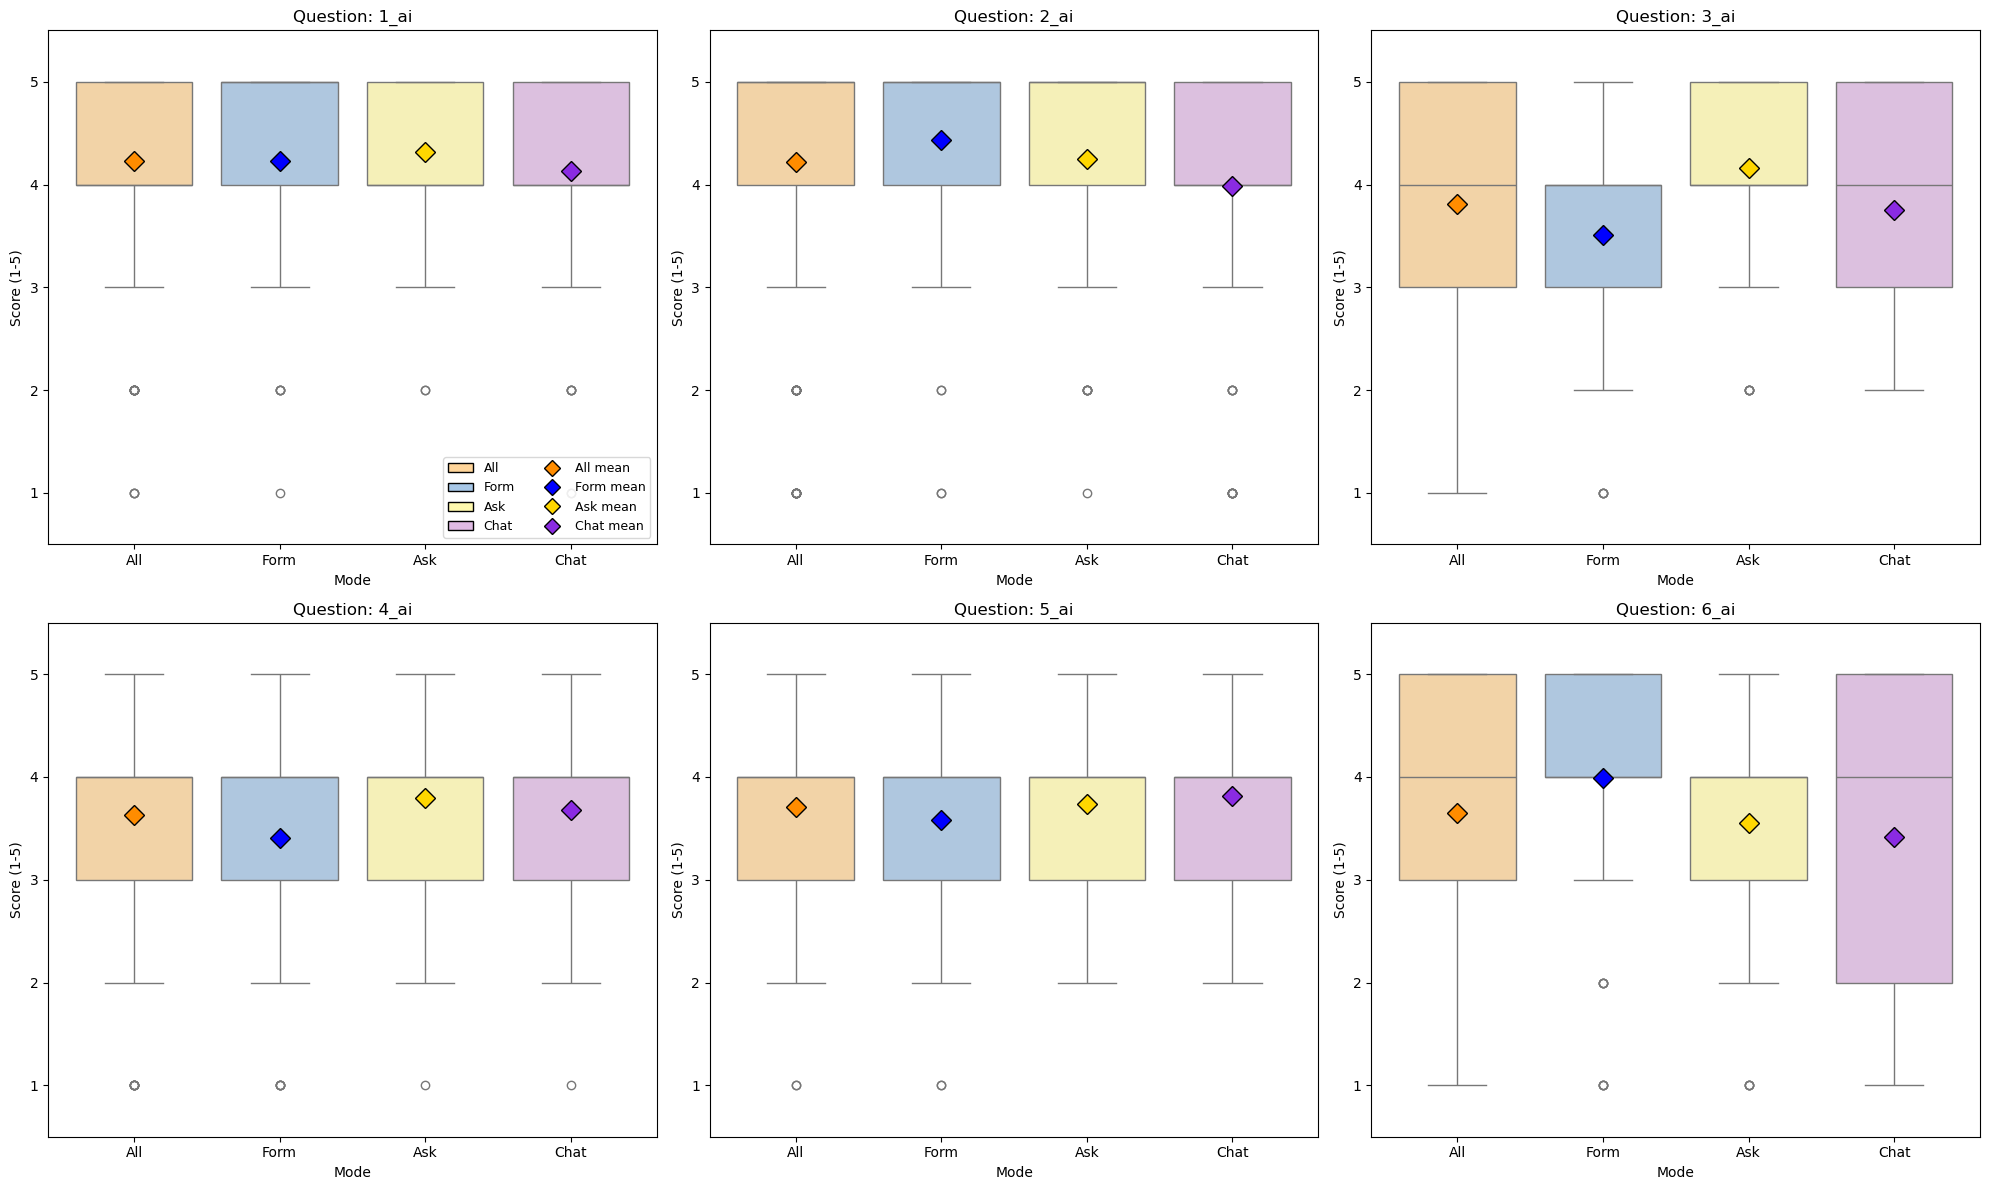

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define color maps including 'All'
ai_pastel_map = {'All': '#FFD59A', 'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
ai_vivid_map = {'All': '#FF8C00', 'Form': '#0000FF', 'Ask': '#FFD700', 'Chat': '#8A2BE2'}
modes_order = ['All', 'Form', 'Ask', 'Chat']

# Prepare the data
def prepare_long_df(df, mode_name):
    long_df = df.melt(var_name='Question', value_name='Score')
    long_df['Mode'] = mode_name
    return long_df

# Create 'All' aggregate
form_df_ai_all = form_df_ai.copy()
ask_df_ai_all = ask_df_ai.copy()
chat_df_ai_all = chat_df_ai.copy()
combined_ai_all = pd.concat([form_df_ai_all, ask_df_ai_all, chat_df_ai_all])

combined_long_df = pd.concat([
    prepare_long_df(combined_ai_all, 'All'),
    prepare_long_df(form_df_ai, 'Form'),
    prepare_long_df(ask_df_ai, 'Ask'),
    prepare_long_df(chat_df_ai, 'Chat')
])

# Create a figure with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
ai_questions = ['1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai']

for i, q in enumerate(ai_questions):
    q_data = combined_long_df[combined_long_df['Question'] == q]

    sns.boxplot(
        data=q_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=axes[i],
        palette=ai_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False
    )

    # Overlay the mean diamond
    for j, mode in enumerate(modes_order):
        vivid_color = ai_vivid_map[mode]
        mean_val = q_data[q_data['Mode'] == mode]['Score'].mean()
        axes[i].plot(j, mean_val, marker='D', color=vivid_color, markersize=10, markeredgecolor='black', zorder=11)

    axes[i].set_title(f'Question: {q}')
    axes[i].set_ylim(0.5, 5.5)
    axes[i].set_yticks([1, 2, 3, 4, 5])
    axes[i].set_ylabel('Score (1-5)')
    axes[i].set_xlabel('Mode')

import matplotlib.patches as mpatches
box_patches = [mpatches.Patch(facecolor=ai_pastel_map[m], edgecolor="black", label=m) for m in modes_order]
mean_handles = [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor=ai_vivid_map[m], markeredgecolor='black', markersize=8, label=f'{m} mean') for m in modes_order]
axes[0].legend(handles=box_patches + mean_handles, loc="lower right", fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")

plt.tight_layout()
plt.savefig(f"{OUT}/ai_subquestions_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Per-item AI Support boxplots: one PNG per item ──────────────────────────
# Splits the 6-panel ai_subquestions_boxplot.png into 6 standalone PNGs so each
# item can be placed individually in the thesis figure environment.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

ai_item_titles = {
    '1_ai': 'AI Item 1 — Helpfulness',
    '2_ai': 'AI Item 2 — Efficiency',
    '3_ai': 'AI Item 3 — Transparency',
    '4_ai': 'AI Item 4 — Trust',
    '5_ai': 'AI Item 5 — Legal Confidence',
    '6_ai': 'AI Item 6 — Reuse Intent',
}
ai_item_files = {
    '1_ai': 'ai_item_1_helpful.png',
    '2_ai': 'ai_item_2_efficiency.png',
    '3_ai': 'ai_item_3_transparency.png',
    '4_ai': 'ai_item_4_trust.png',
    '5_ai': 'ai_item_5_legal.png',
    '6_ai': 'ai_item_6_reuse.png',
}

for q in ['1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai']:
    q_data = combined_long_df[combined_long_df['Question'] == q]

    fig, ax = plt.subplots(figsize=(6.0, 4.5))

    sns.boxplot(
        data=q_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=ax,
        palette=ai_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False,
    )

    for j, mode in enumerate(modes_order):
        vivid_color = ai_vivid_map[mode]
        mean_val = q_data[q_data['Mode'] == mode]['Score'].mean()
        ax.plot(j, mean_val, marker='D', color=vivid_color,
                markersize=10, markeredgecolor='black', zorder=11)

    ax.set_title(ai_item_titles[q], fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Score (1–5)')
    ax.set_xlabel('Mode')
    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=ai_pastel_map[m], edgecolor='black', label=m)
        for m in modes_order
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker='D', color='w',
                   markerfacecolor=ai_vivid_map[m], markeredgecolor='black',
                   markersize=8, label=f'{m} mean')
        for m in modes_order
    ]
    ax.legend(handles=box_patches + mean_handles, loc='lower right',
              fontsize=8, ncol=2, framealpha=0.88, edgecolor='lightgrey')

    fname = f"{OUT}/{ai_item_files[q]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved → {fname}")


In [4]:
import pandas as pd
import numpy as np

# Programmatic per-item descriptive frame for AI Support
# (matches the structure used for SUS and TLX further below).
ai_cols = ['1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai']
combined_ai_all = pd.concat([form_df_ai, ask_df_ai, chat_df_ai])

modes_data = {
    'All': combined_ai_all,
    'Form': form_df_ai,
    'Ask': ask_df_ai,
    'Chat': chat_df_ai,
}

ai_stats_list = []
for mode_name, mode_df in modes_data.items():
    for col in ai_cols:
        desc = mode_df[col].describe()
        m_val = mode_df[col].mode()
        mode_result = m_val[0] if not m_val.empty else np.nan
        ai_stats_list.append({
            'Mode': mode_name,
            'Question': col,
            'Mean': desc['mean'],
            'Median': desc['50%'],
            'Mode_Value': mode_result,
            'Std_Dev': desc['std'],
            'Variance': mode_df[col].var(),
            'Min': desc['min'],
            'Q1': desc['25%'],
            'Q2': desc['50%'],
            'Q3': desc['75%'],
            'Max': desc['max'],
        })

ai_summary_df = pd.DataFrame(ai_stats_list)
ai_summary_df.to_csv(f'{OUT}/ai_support_per_item_summary.csv', index=False)
print('AI Support Descriptive Statistics Summary:')
display(ai_summary_df)

AI Support Descriptive Statistics Summary:


,Mode,Question,Mean,Median,Mode_Value,Std_Dev,Variance,Min,Q1,Q2,Q3,Max
0,All,1_ai,4.227053,4.0,5,0.914629,0.836546,1.0,4.0,4.0,5.0,5.0
1,All,2_ai,4.222222,5.0,5,1.127283,1.270766,1.0,4.0,5.0,5.0,5.0
2,All,3_ai,3.806763,4.0,4,1.057269,1.117818,1.0,3.0,4.0,5.0,5.0
3,All,4_ai,3.628019,4.0,4,0.971331,0.943483,1.0,3.0,4.0,4.0,5.0
4,All,5_ai,3.710145,4.0,4,0.882980,0.779654,1.0,3.0,4.0,4.0,5.0
5,All,6_ai,3.652174,4.0,4,1.252098,1.567750,1.0,3.0,4.0,5.0,5.0
6,Form,1_ai,4.231884,5.0,5,0.972337,0.945439,1.0,4.0,5.0,5.0,5.0
7,Form,2_ai,4.434783,5.0,5,0.962201,0.925831,1.0,4.0,5.0,5.0,5.0
8,Form,3_ai,3.507246,4.0,4,1.171012,1.371270,1.0,3.0,4.0,4.0,5.0
9,Form,4_ai,3.405797,4.0,4,1.088967,1.185848,1.0,3.0,4.0,4.0,5.0


### Interpretation of Overall AI Scores

By averaging the scores across all six dimensions to form a **Perceived AI Support** composite (note: this is *not* a confidence construct — only one of the six items, 5_ai, is about confidence in correctness) (helpfulness, efficiency, transparency, trust, legal confidence, and re-use intent), we get a single summary score per mode:

| Mode | Grand Mean (1–5) |
|------|----------------|
| Ask  | 3.97 |
| Form | 3.86 |
| Chat | 3.80 |

Ask mode scores highest on this Perceived AI Support composite, driven primarily by its higher transparency and trust ratings. Form scores well because of its efficiency advantage, even though it lags on transparency. Chat ranks third overall but shows the most variance across subscales — it is rated highest on legal-basis confidence (item 5_ai, the primary RQ2 confidence measure) but lowest on re-use intent (6_ai).

However, the Friedman test (see Statistical Significance Analysis below) finds **no statistically significant difference** between modes on the overall AI score (χ²(2) = 1.049, p = 0.592, Kendall's W = 0.008 — negligible effect). This means the aggregate scores are too close to rule out chance variation with this sample size. The rankings above are directional trends, not established findings.


Overall AI Scores per Mode (Mean of Means):


,Mode,Overall_AI_Score
0,Ask,3.968599
2,Form,3.857488
1,Chat,3.797101


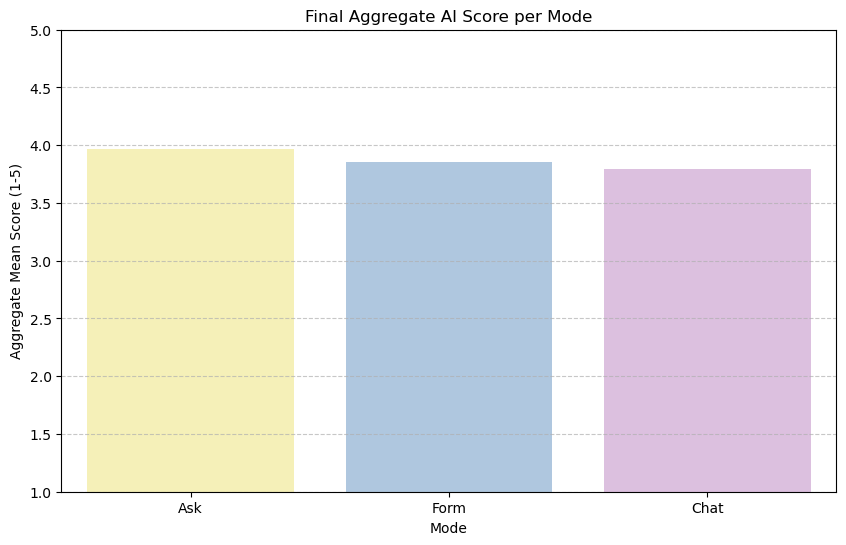

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse `ai_summary_df` built above. Compute the per-mode grand mean of the
# six item means and visualise it (excluding the 'All' aggregate row).
overall_scores = (
    ai_summary_df[ai_summary_df['Mode'] != 'All']
    .groupby('Mode')['Mean'].mean()
    .reset_index()
    .rename(columns={'Mean': 'Overall_AI_Score'})
    .sort_values(by='Overall_AI_Score', ascending=False)
)

print("Overall AI Scores per Mode (Mean of Means):")
display(overall_scores)

# Visualize the final comparison with pastel colors
plt.figure(figsize=(10, 6))
pastel_colors = {'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
sns.barplot(data=overall_scores, x='Mode', y='Overall_AI_Score',
            hue='Mode', palette=pastel_colors, legend=False)
plt.title('Final Aggregate AI Score per Mode')
plt.ylim(1, 5)
plt.ylabel('Aggregate Mean Score (1-5)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### The Preference–Quality Gap (RQ2 Preview)

There is an important pattern in the data: **Ask mode** receives the highest AI helpfulness rating (Grand Mean 3.97) and the highest transparency score (4.16), yet it is the *least preferred* mode in the final rankings. This gap between perceived AI quality and stated preference is largely explained by usability friction — specifically, the requirement to manually copy-paste AI responses into document fields (see qualitative feedback and RTLX results below).

A related and distinct question for RQ2 is whether users' **legal confidence** (5_ai: 'I am confident the AI identified the correct legal basis') tracks actual document quality. The confidence scores across modes are similar (Form 3.58, Ask 3.74, Chat 3.81 on a 1–5 scale). Whether this confidence is warranted — and whether it varies in the same direction as objective NLP metrics (BERTScore F1, SBERT similarity) — can only be established by cross-referencing with the metrics notebook.


# SUS score

| Variable | Item (DE)                                                                                                     |
| -------- | ------------------------------------------------------------------------------------------------------------- |
| x_1_sus  | Ich denke, dass ich dieses System häufig nutzen möchte.                                                       |
| x_2_sus  | Ich fand das System unnötig kompliziert.                                                                      |
| x_3_sus  | Ich fand das System einfach zu bedienen.                                                                      |
| x_4_sus  | Ich glaube, ich bräuchte die Unterstützung einer technischen Person, um dieses System nutzen zu können.       |
| x_5_sus  | Ich fand, dass die verschiedenen Funktionen in diesem System gut integriert waren.                            |
| x_6_sus  | Ich fand, dass dieses System zu inkonsequent war.                                                             |
| x_7_sus  | Ich könnte mir vorstellen, dass die meisten Menschen sehr schnell lernen würden, mit diesem System umzugehen. |
| x_8_sus  | Ich fand das System sehr umständlich zu bedienen.                                                             |
| x_9_sus  | Ich fühlte mich sehr sicher im Umgang mit dem System.                                                         |
| x_10_sus | Ich musste eine Menge lernen, bevor ich mit diesem System loslegen konnte.                                    |


## System Usability Scale (SUS) Scoring

The **SUS score** is calculated as follows:

### 1) Convert each item score

- For **odd-numbered items** (**1, 3, 5, 7, 9**) — these are **positive statements**:  
  **converted score = response value - 1**

- For **even-numbered items** (**2, 4, 6, 8, 10**) — these are **negative statements**:  
  **converted score = 5 - response value**

### 2) Calculate the total SUS score

- Sum all **10 converted scores**
- Multiply the total by **2.5**

**Formula:**

`SUS Score = (sum of all converted item scores) × 2.5`

This produces a final score from **0 to 100**.

## Interpretation Benchmarks

| Score | Grade | Label |
|---|---|---|
| ≥ 90 | A+ | Best Imaginable |
| 85–89 | A | Excellent |
| 80–84 | B | Good |
| 70–79 | C | OK |
| 60–69 | D | Poor |
| < 60 | F | Awful |

## Threshold for Acceptability

The commonly cited **acceptable threshold** is **68**.

- **Scores below 68** suggest usability problems worth addressing.
- **Scores at or above 68** are generally considered acceptable.

## Response Scale

The SUS uses a **1–5 Likert scale**:

1. **Strongly Disagree**  
2. **Disagree**  
3. **Neutral**  
4. **Agree**  
5. **Strongly Agree**


In addition we will evaluate the following values for the SUS subquestion groups:

Mean (Average): The sum of all values divided by the number of values; it identifies the center of the data.
Median: The middle value when data is ordered from lowest to highest, used to find the center without being affected by extreme outliers.
Mode: The value that occurs with the greatest frequency.
Standard Deviation: Measures the amount of variation or dispersion of a set of values from the mean.
Variance: The average of the squared differences from the mean, providing a measure of how spread out the data is
Minimum: The lowest value.
Lower Quartile (Q1): The 25th percentile.
Median (Q2): The 50th percentile.
Upper Quartile (Q3): The 75th percentile.
Maximum: The highest value.

# Task
# Task: Perform System Usability Scale (SUS) Evaluation for ROPAgen Modes

From the filtered DataFrames `form_df`, `ask_df`, and `chat_df` (where `p_0001 >= 1`), conduct a comprehensive SUS analysis for the three interaction modes (Form, Ask, Chat):

1.  **Initialize SUS Sub-DataFrames**: Create `form_df_sus`, `ask_df_sus`, and `chat_df_sus` containing only the SUS-related columns (`1_sus` through `10_sus`).
2.  **Calculate Descriptive Statistics**: For each of the 10 SUS questions across all three modes, calculate the Mean, Median, Mode, Standard Deviation, Variance, Min, Q1, Q2, Q3, and Max.
3.  **Calculate Final SUS Scores**:
    *   Implement the SUS scoring logic: convert odd items (score - 1) and even items (5 - score).
    *   Sum the converted scores for each participant and multiply by 2.5 to get the individual SUS score (0-100).
    *   Calculate the mean SUS score for each mode.
4.  **Visualize SUS Scores**:
    *   Create a grid of boxplots (2 rows, 5 columns) to compare the three modes for each of the 10 SUS questions.
    *   Use the color scheme: **Form** (Blue), **Ask** (Yellow), and **Chat** (Lilac - #C8A2C8).
5.  **Summary and Interpretation**: Present a final summary including the statistical table for subquestions, the final SUS scores per mode, and an interpretation of the results based on the acceptability threshold of 68.

## Initialize SUS Sub-DataFrames

### Subtask:
Filter the existing DataFrames for valid participants and extract the 10 SUS-related columns into mode-specific sub-DataFrames.


**Reasoning**:
I will initialize the SUS-specific sub-DataFrames by filtering for valid participants and selecting the relevant columns for Form, Ask, and Chat modes.



In [6]:
sus_cols = ['1_sus', '2_sus', '3_sus', '4_sus', '5_sus', '6_sus', '7_sus', '8_sus', '9_sus', '10_sus']

# Filter for valid participants (p_0001 >= 1) and select SUS columns
form_df_sus = form_df[form_df['p_0001'] >= 1][sus_cols]
ask_df_sus = ask_df[ask_df['p_0001'] >= 1][sus_cols]
chat_df_sus = chat_df[chat_df['p_0001'] >= 1][sus_cols]

# Verification
print(f'form_df_sus shape: {form_df_sus.shape}')
print(f'ask_df_sus shape: {ask_df_sus.shape}')
print(f'chat_df_sus shape: {chat_df_sus.shape}')

form_df_sus shape: (69, 10)
ask_df_sus shape: (69, 10)
chat_df_sus shape: (69, 10)


## Calculate Descriptive Statistics per Subquestion

### Subtask:
Calculate a comprehensive set of descriptive statistics for each of the 10 SUS questions across the three mode-specific DataFrames (Form, Ask, Chat).


In [7]:
import pandas as pd
import numpy as np

sus_cols = ['1_sus', '2_sus', '3_sus', '4_sus', '5_sus', '6_sus', '7_sus', '8_sus', '9_sus', '10_sus']
combined_sus_all = pd.concat([form_df_sus, ask_df_sus, chat_df_sus])

modes_data = {
    'All': combined_sus_all,
    'Form': form_df_sus,
    'Ask': ask_df_sus,
    'Chat': chat_df_sus
}

stats_list = []

for mode_name, mode_df in modes_data.items():
    for col in sus_cols:
        desc = mode_df[col].describe()
        m_val = mode_df[col].mode()
        mode_result = m_val[0] if not m_val.empty else np.nan

        stats_list.append({
            'Mode': mode_name,
            'Question': col,
            'Mean': desc['mean'],
            'Median': desc['50%'],
            'Mode_Value': mode_result,
            'Std_Dev': desc['std'],
            'Variance': mode_df[col].var(),
            'Min': desc['min'],
            'Q1': desc['25%'],
            'Q2': desc['50%'],
            'Q3': desc['75%'],
            'Max': desc['max']
        })

sus_summary_df = pd.DataFrame(stats_list)
print("Corrected SUS Descriptive Statistics Summary (including 'All' mode):")
display(sus_summary_df)
sus_summary_df.to_csv(f'{OUT}/sus_per_item_summary.csv', index=False)

Corrected SUS Descriptive Statistics Summary (including 'All' mode):


,Mode,Question,Mean,Median,Mode_Value,Std_Dev,Variance,Min,Q1,Q2,Q3,Max
0,All,1_sus,3.318841,3.0,4,1.142635,1.305614,1.0,3.0,3.0,4.0,5.0
1,All,2_sus,2.000000,2.0,1,1.119119,1.252427,1.0,1.0,2.0,3.0,5.0
2,All,3_sus,4.125604,4.0,5,0.972272,0.945312,1.0,4.0,4.0,5.0,5.0
3,All,4_sus,1.521739,1.0,1,0.885844,0.784719,1.0,1.0,1.0,2.0,5.0
4,All,5_sus,3.768116,4.0,4,1.049432,1.101309,1.0,3.0,4.0,5.0,5.0
5,All,6_sus,2.072464,2.0,1,0.999789,0.999578,1.0,1.0,2.0,3.0,5.0
6,All,7_sus,4.111111,4.0,5,0.981490,0.963323,1.0,4.0,4.0,5.0,5.0
7,All,8_sus,2.033816,2.0,1,1.129402,1.275550,1.0,1.0,2.0,3.0,5.0
8,All,9_sus,3.855072,4.0,4,1.041965,1.085690,1.0,3.0,4.0,5.0,5.0
9,All,10_sus,1.613527,1.0,1,0.900599,0.811078,1.0,1.0,1.0,2.0,5.0


## Calculate Final SUS Scores

### Subtask:
Implement the SUS scoring logic to calculate individual scores for each participant and the mean SUS score for each mode (Form, Ask, Chat).


**Reasoning**:
I will implement the SUS scoring logic by converting the raw scores according to the SUS methodology (score-1 for odd items, 5-score for even items), then calculating the final score for each participant in the Form, Ask, and Chat modes.



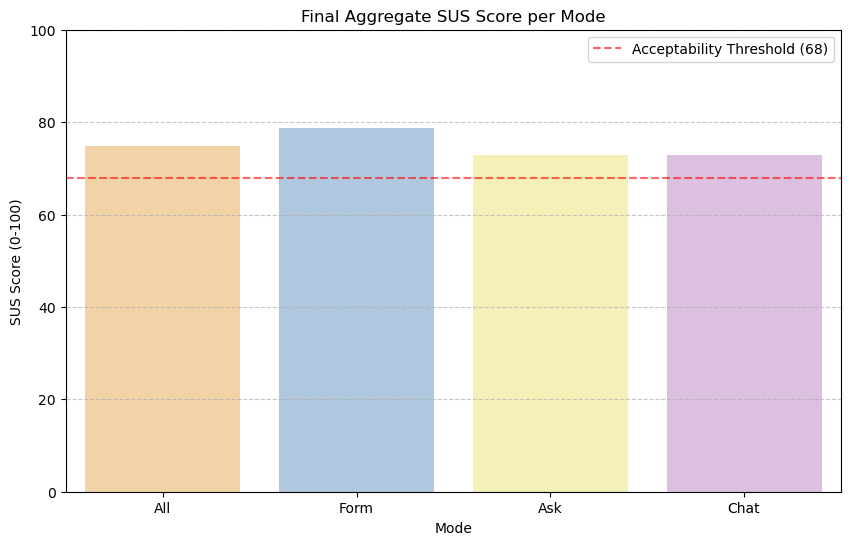

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

odd_cols = ['1_sus', '3_sus', '5_sus', '7_sus', '9_sus']
even_cols = ['2_sus', '4_sus', '6_sus', '8_sus', '10_sus']

def calculate_sus_score(df):
    converted_df = df.copy()
    for col in odd_cols:
        converted_df[col] = df[col] - 1
    for col in even_cols:
        converted_df[col] = 5 - df[col]
    return converted_df[sus_cols].sum(axis=1) * 2.5

# Calculate and store final scores
form_df_sus['SUS_Score'] = calculate_sus_score(form_df_sus)
ask_df_sus['SUS_Score'] = calculate_sus_score(ask_df_sus)
chat_df_sus['SUS_Score'] = calculate_sus_score(chat_df_sus)

# Prepare SUS plot data
sus_scores_summary = [
    {'Mode': 'All', 'SUS_Score': pd.concat([form_df_sus['SUS_Score'], ask_df_sus['SUS_Score'], chat_df_sus['SUS_Score']]).mean()},
    {'Mode': 'Form', 'SUS_Score': form_df_sus['SUS_Score'].mean()},
    {'Mode': 'Ask', 'SUS_Score': ask_df_sus['SUS_Score'].mean()},
    {'Mode': 'Chat', 'SUS_Score': chat_df_sus['SUS_Score'].mean()}
]
sus_plot_df = pd.DataFrame(sus_scores_summary)

# Visualization
plt.figure(figsize=(10, 6))
pastel_map = {'All': '#FFD59A', 'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
sns.barplot(data=sus_plot_df, x='Mode', y='SUS_Score', hue='Mode', palette=pastel_map, legend=False)
plt.axhline(68, color='red', linestyle='--', alpha=0.6, label='Acceptability Threshold (68)')
plt.title('Final Aggregate SUS Score per Mode')
plt.ylim(0, 100)
plt.ylabel('SUS Score (0-100)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{OUT}/sus_aggregate_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualize SUS Scores with Boxplots

### Subtask:
Create a grid of boxplots to compare the three interaction modes across all 10 SUS questions using the specified color scheme.


**Reasoning**:
I will create a visualization using a 2x5 grid of boxplots to compare the three interaction modes (Form, Ask, Chat) across all 10 SUS questions, applying the specific color palette and scale constraints as requested.



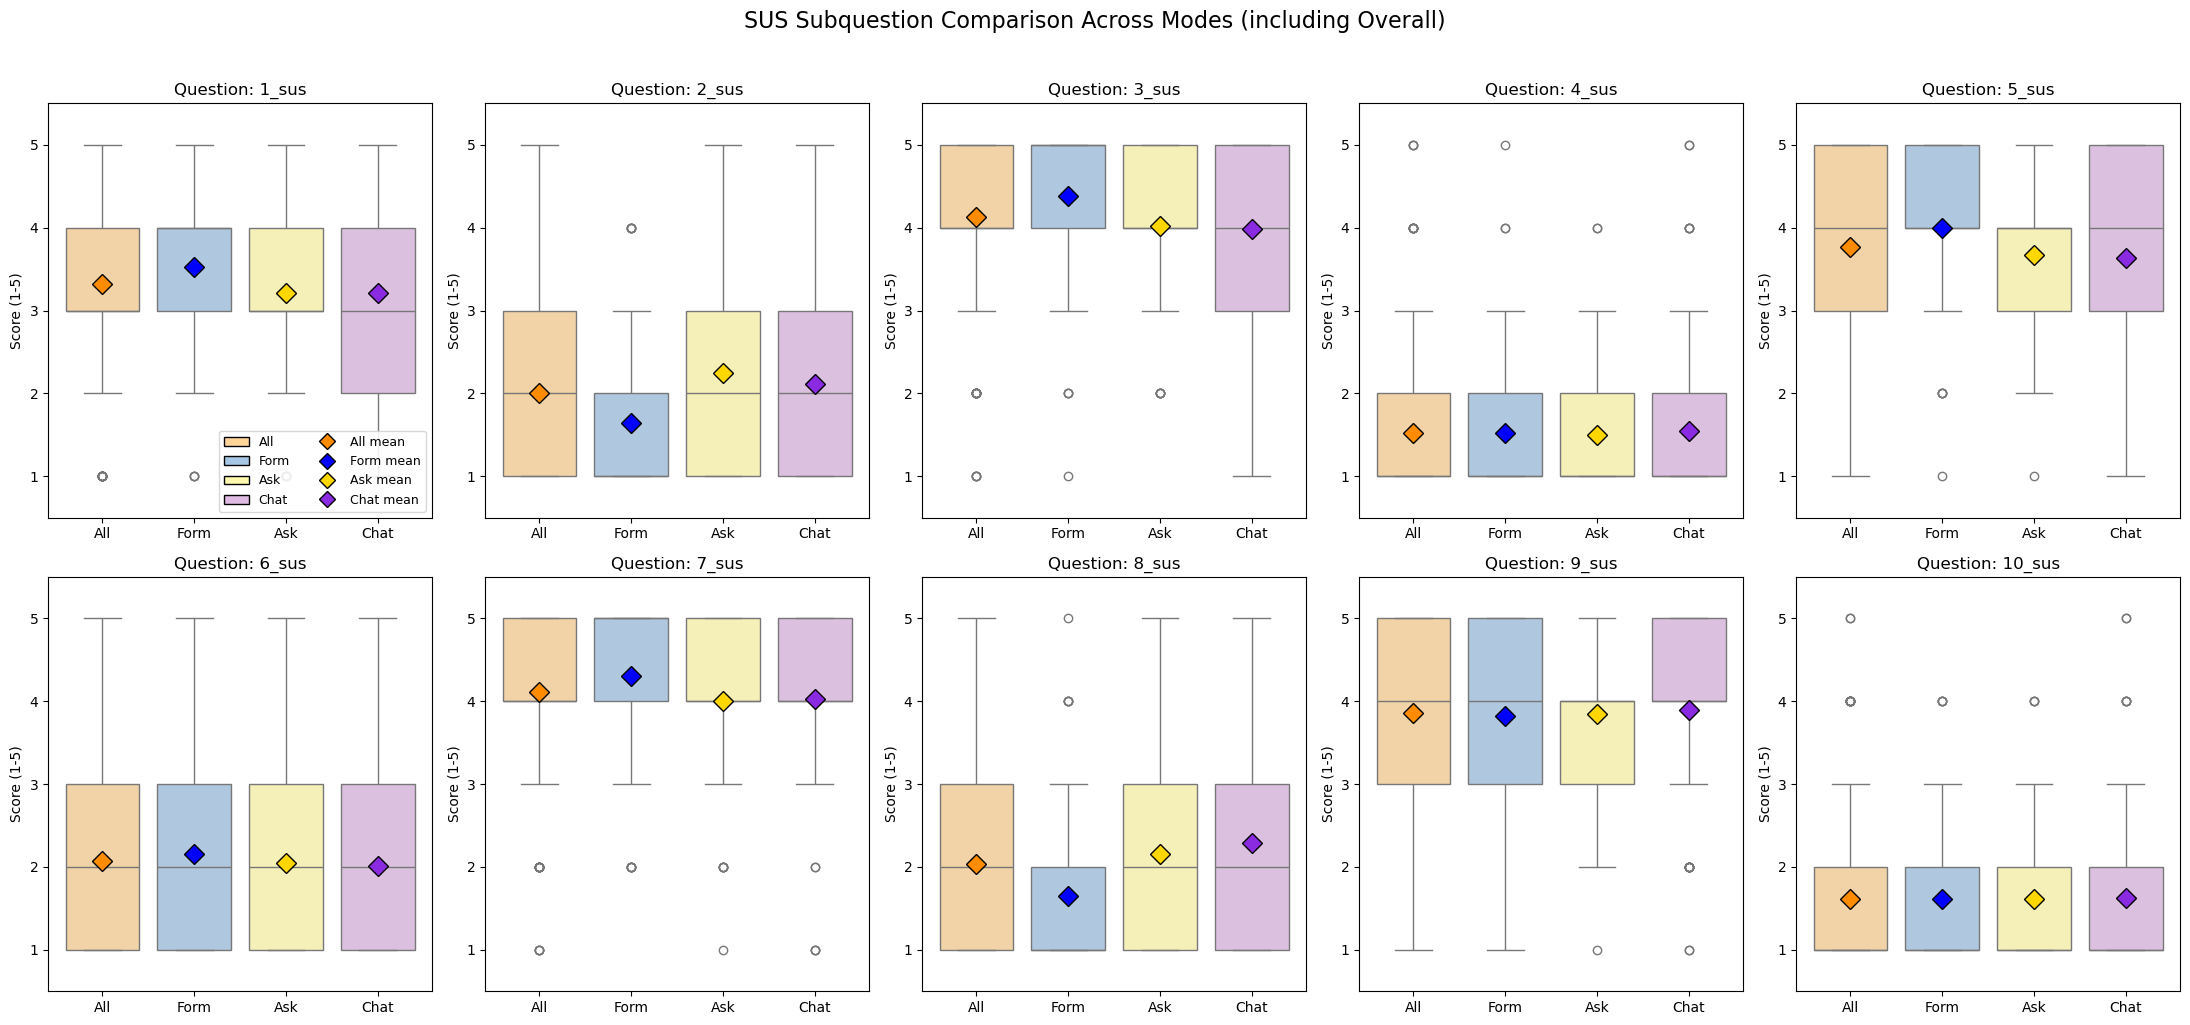

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define color maps including 'All'
sus_pastel_map = {'All': '#FFD59A', 'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
sus_vivid_map = {'All': '#FF8C00', 'Form': '#0000FF', 'Ask': '#FFD700', 'Chat': '#8A2BE2'}
modes_order = ['All', 'Form', 'Ask', 'Chat']
sus_cols = ['1_sus', '2_sus', '3_sus', '4_sus', '5_sus', '6_sus', '7_sus', '8_sus', '9_sus', '10_sus']

# Prepare data
def melt_sus(df, mode_name):
    temp = df[sus_cols].copy()
    long_df = temp.melt(var_name='Question', value_name='Score')
    long_df['Mode'] = mode_name
    return long_df

# Create 'All' aggregate
combined_sus_all = pd.concat([form_df_sus[sus_cols], ask_df_sus[sus_cols], chat_df_sus[sus_cols]])

combined_sus_long = pd.concat([
    melt_sus(combined_sus_all, 'All'),
    melt_sus(form_df_sus, 'Form'),
    melt_sus(ask_df_sus, 'Ask'),
    melt_sus(chat_df_sus, 'Chat')
])

# Create 2x5 grid of subplots
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(sus_cols):
    q_data = combined_sus_long[combined_sus_long['Question'] == col]

    sns.boxplot(
        data=q_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=axes[i],
        palette=sus_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False
    )

    # Overlay the mean diamond
    for j, mode in enumerate(modes_order):
        vivid_color = sus_vivid_map[mode]
        mean_val = q_data[q_data['Mode'] == mode]['Score'].mean()
        axes[i].plot(j, mean_val, marker='D', color=vivid_color, markersize=10, markeredgecolor='black', zorder=11)

    axes[i].set_title(f'Question: {col}')
    axes[i].set_ylim(0.5, 5.5)
    axes[i].set_yticks([1, 2, 3, 4, 5])
    axes[i].set_ylabel('Score (1-5)')
    axes[i].set_xlabel('')

import matplotlib.patches as mpatches
box_patches = [mpatches.Patch(facecolor=sus_pastel_map[m], edgecolor="black", label=m) for m in modes_order]
mean_handles = [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor=sus_vivid_map[m], markeredgecolor='black', markersize=8, label=f'{m} mean') for m in modes_order]
axes[0].legend(handles=box_patches + mean_handles, loc="lower right", fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")

plt.suptitle('SUS Subquestion Comparison Across Modes (including Overall)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT}/sus_subquestions_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Per-item SUS boxplots: one PNG per item ─────────────────────────────────
# Splits the 10-panel sus_subquestions_boxplot.png into 10 standalone PNGs.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sus_item_titles = {
    '1_sus':  'SUS Item 1 — Would use frequently',
    '2_sus':  'SUS Item 2 — Unnecessarily complex',
    '3_sus':  'SUS Item 3 — Easy to use',
    '4_sus':  'SUS Item 4 — Needs technical support',
    '5_sus':  'SUS Item 5 — Functions well integrated',
    '6_sus':  'SUS Item 6 — Too much inconsistency',
    '7_sus':  'SUS Item 7 — Most people learn quickly',
    '8_sus':  'SUS Item 8 — Cumbersome to use',
    '9_sus':  'SUS Item 9 — Felt confident',
    '10_sus': 'SUS Item 10 — Needed to learn a lot',
}
sus_item_files = {
    '1_sus':  'sus_item_01.png',
    '2_sus':  'sus_item_02.png',
    '3_sus':  'sus_item_03.png',
    '4_sus':  'sus_item_04.png',
    '5_sus':  'sus_item_05.png',
    '6_sus':  'sus_item_06.png',
    '7_sus':  'sus_item_07.png',
    '8_sus':  'sus_item_08.png',
    '9_sus':  'sus_item_09.png',
    '10_sus': 'sus_item_10.png',
}

for col in sus_cols:
    q_data = combined_sus_long[combined_sus_long['Question'] == col]

    fig, ax = plt.subplots(figsize=(6.0, 4.5))

    sns.boxplot(
        data=q_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=ax,
        palette=sus_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False,
    )

    for j, mode in enumerate(modes_order):
        vivid_color = sus_vivid_map[mode]
        mean_val = q_data[q_data['Mode'] == mode]['Score'].mean()
        ax.plot(j, mean_val, marker='D', color=vivid_color,
                markersize=10, markeredgecolor='black', zorder=11)

    ax.set_title(sus_item_titles[col], fontsize=12, fontweight='bold')
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Score (1–5)')
    ax.set_xlabel('Mode')
    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=sus_pastel_map[m], edgecolor='black', label=m)
        for m in modes_order
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker='D', color='w',
                   markerfacecolor=sus_vivid_map[m], markeredgecolor='black',
                   markersize=8, label=f'{m} mean')
        for m in modes_order
    ]
    ax.legend(handles=box_patches + mean_handles, loc='lower right',
              fontsize=8, ncol=2, framealpha=0.88, edgecolor='lightgrey')

    fname = f"{OUT}/{sus_item_files[col]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved → {fname}")


## Final Task

### Subtask:
Summarize the SUS findings, including the statistical table for subquestions, the final SUS scores per mode, and an interpretation based on the acceptability benchmarks.


## Summary:

### Q&A

**What are the final SUS scores for each ROPAgen interaction mode?**
*   **Form**: 78.62
*   **Ask**: 72.97
*   **Chat**: 72.93

**How do these scores compare to established SUS benchmarks?**
SUS scores are typically interpreted using the grading scale proposed by Bangor et al. (2008) and refined by Sauro & Lewis (2011):
- **> 85**: Excellent (Grade A)
- **71–85**: Good (Grade B)
- **50–70**: Marginal/OK (Grade C–D)
- **< 50**: Unacceptable (Grade F)

The population average SUS score is approximately **68**. All three ROPAgen modes exceed this average. All three modes fall in the **Good (Grade B)** range. Form (78.62) sits solidly in Good territory; Ask (72.97) and Chat (72.93) are at the lower end of Good. The Friedman test shows a marginal trend (χ²(2) = 5.510, p = 0.064, Kendall's W = 0.040 — negligible effect) that does not reach significance at α = 0.05.

### Data Analysis Key Findings

*   **Sample**: 69 valid participants across all three modes.
*   **Subquestion performance**:
    *   Positive items (e.g., `3_sus` — ease of use) scored high, especially in Form (mean ≈ 4.38).
    *   Negative items (e.g., `2_sus` — perceived complexity) remained low (Form mean ≈ 1.64), indicating the system is not seen as complex in any mode.
*   **Comparative usability**: Form (78.62) > Ask (72.97) ≈ Chat (72.93). The gap between Form and the conversational modes is approximately 5.7 SUS points. All three modes are rated **Good**.
*   **Variance**: Chat and Ask show slightly greater response variability on negative SUS items, suggesting more divergent user experiences than in Form.

### Insights
*   All modes clear the Good threshold — no mode is considered poor from a usability standpoint.
*   The similar SUS scores for Ask and Chat suggest they face comparable usability challenges, likely driven by response latency and interaction effort rather than structural complexity.
*   Effect sizes remain negligible (Kendall's W ≈ 0.04), indicating the Form advantage is small in magnitude even if directionally consistent.


# TLX score

## NASA-TLX — Raw TLX (RTLX) Method

The **NASA Task Load Index (NASA-TLX)** is a widely used questionnaire for assessing perceived cognitive workload. The standard NASA-TLX includes a pairwise weighting step where participants rank which subscales matter most to them personally; this produces individualised weights. The simpler **Raw TLX (RTLX)** omits this weighting step and simply averages the six subscale scores equally. Research by Hart (2006) shows that RTLX performs comparably to the full weighted version in most settings. **This study uses RTLX.**

### 1) Subscales and rating scale (1–21)

| Variable | Subscale | Question (DE) | Higher score means... |
|---|---|---|---|
| `1_tlx_demand` | Mental Demand | Wie anspruchsvoll war die Aufgabe für Sie? | More mental effort required |
| `2_tlx_demand` | Physical Demand | Wie körperlich anstrengend war die Aufgabe? | More physical effort required |
| `3_tlx_demand` | Temporal Demand | Wie eilig oder gehetzt war das Tempo der Aufgabe? | More time pressure felt |
| `4_tlx_demand` | Effort | Wie hart mussten Sie arbeiten, um Ihr Leistungsniveau zu erreichen? | More effort expended |
| `5_tlx_demand` | Frustration | Wie verunsichert, entmutigt, gereizt, gestresst und genervt waren Sie? | More frustration experienced |
| `1_tlx_performance` | Performance | Wie erfolgreich waren Sie bei der Erledigung der Ihnen gestellten Aufgabe? | **More successful** (positive direction) |

**Note on Performance subscale polarity**: In the standard NASA-TLX, the Performance item is reverse-coded — a *high* score means *poor* performance (the question asks how much failure you experienced). This survey's German phrasing ('Wie erfolgreich waren Sie?') runs in the **positive direction** (higher = more successful). As a consequence, the Performance item pulls the RTLX average *downward* (toward lower apparent workload) when participants rate themselves as successful. The five demand/frustration items all run in the negative direction (higher = worse). This asymmetry means the RTLX total should not be interpreted as a pure workload score; Performance should be examined separately.

### 2) RTLX Scoring

RTLX is calculated as the unweighted mean of all six subscale scores per participant:

**Formula:** `RTLX = (Σ subscale_i) / 6`

### 3) Score interpretation (1–21 scale)

There is no single universally agreed benchmark for RTLX on a 1–21 scale. A reasonable heuristic is to treat the midpoint of 11 as moderate workload. Values well below 11 indicate low workload on the demand/frustration subscales; because Performance is positive-coded, a low total can also reflect high self-rated success. Values above 15 indicate high workload or poor performance.


# Task
From the filtered DataFrames `form_df`, `ask_df`, and `chat_df` (where `p_0001 >= 1`), perform a comprehensive NASA-TLX workload evaluation for the three ROPAgen interaction modes:

1.  **Initialize TLX Sub-DataFrames**: Create `form_df_tlx`, `ask_df_tlx`, and `chat_df_tlx` containing only the NASA-TLX columns (`1_tlx_demand` through `5_tlx_demand` and `1_tlx_performance`).
2.  **Calculate Descriptive Statistics per Subquestion**: For each of the 6 NASA-TLX items, calculate the Mean, Median, Mode, Standard Deviation, Variance, Min, Q1, Q2, Q3, and Max for the Form, Ask, and Chat modes.
3.  **Calculate RTLX Scores**: Implement the Raw TLX (RTLX) scoring logic by calculating the average of all 6 dimensions for each participant to create an `Overall_Workload_Score`. Calculate the final mean RTLX score for each mode.
4.  **Visualize TLX Scores with Boxplots**: Create a grid of boxplots (2 rows, 3 columns) to compare the three modes for each of the 6 NASA-TLX items. Use the following color scheme:
    *   **Form**: Blue
    *   **Ask**: Yellow
    *   **Chat**: Lilac (#C8A2C8)
    Ensure the y-axis is set to the 1-21 scale used in the survey.
5.  **Final Task Summary**: Summarize the TLX findings using the RTLX method, including a comprehensive statistical table, the final RTLX scores per mode, and an interpretation of the cognitive workload across interaction strategies.

## Initialize TLX Sub-DataFrames

### Subtask:
Filter the existing DataFrames for valid participants and extract the NASA-TLX-related columns into mode-specific sub-DataFrames.


**Reasoning**:
I will initialize the TLX-specific sub-DataFrames by filtering for valid participants (p_0001 >= 1) and selecting the relevant NASA-TLX columns for Form, Ask, and Chat modes, then verify their shapes.



In [10]:
tlx_cols = ['1_tlx_demand', '2_tlx_demand', '3_tlx_demand', '4_tlx_demand', '5_tlx_demand', '1_tlx_performance']

# Filter for valid participants (p_0001 >= 1) and select TLX columns
form_df_tlx = form_df[form_df['p_0001'] >= 1][tlx_cols]
ask_df_tlx = ask_df[ask_df['p_0001'] >= 1][tlx_cols]
chat_df_tlx = chat_df[chat_df['p_0001'] >= 1][tlx_cols]

# Verification of shapes
print(f'form_df_tlx shape: {form_df_tlx.shape}')
print(f'ask_df_tlx shape: {ask_df_tlx.shape}')
print(f'chat_df_tlx shape: {chat_df_tlx.shape}')

form_df_tlx shape: (69, 6)
ask_df_tlx shape: (69, 6)
chat_df_tlx shape: (69, 6)


## Calculate Descriptive Statistics per Subquestion

### Subtask:
Calculate a comprehensive set of descriptive statistics for each of the 6 NASA-TLX items across the three mode-specific DataFrames (Form, Ask, Chat).


**Reasoning**:
I will calculate the descriptive statistics for each of the 6 NASA-TLX items across the three mode-specific DataFrames (Form, Ask, Chat) as instructed, ensuring all required metrics are included in a consolidated summary DataFrame.



In [11]:
import pandas as pd
import numpy as np

tlx_cols = ['1_tlx_demand', '2_tlx_demand', '3_tlx_demand', '4_tlx_demand', '5_tlx_demand', '1_tlx_performance']
combined_tlx_all = pd.concat([form_df_tlx, ask_df_tlx, chat_df_tlx])

modes_tlx_data = {
    'All': combined_tlx_all,
    'Form': form_df_tlx,
    'Ask': ask_df_tlx,
    'Chat': chat_df_tlx
}

tlx_stats_list = []

for mode_name, mode_df in modes_tlx_data.items():
    for col in tlx_cols:
        desc = mode_df[col].describe()
        m_val = mode_df[col].mode()
        mode_result = m_val[0] if not m_val.empty else np.nan

        tlx_stats_list.append({
            'Mode': mode_name,
            'Question': col,
            'Mean': desc['mean'],
            'Median': desc['50%'],
            'Mode_Value': mode_result,
            'Std_Dev': desc['std'],
            'Variance': mode_df[col].var(),
            'Min': desc['min'],
            'Q1': desc['25%'],
            'Q2': desc['50%'],
            'Q3': desc['75%'],
            'Max': desc['max']
        })

tlx_summary_df = pd.DataFrame(tlx_stats_list)
print("NASA-TLX Descriptive Statistics Summary (including 'All' mode):")
display(tlx_summary_df)
tlx_summary_df.to_csv(f'{OUT}/tlx_per_item_summary.csv', index=False)

NASA-TLX Descriptive Statistics Summary (including 'All' mode):


,Mode,Question,Mean,Median,Mode_Value,Std_Dev,Variance,Min,Q1,Q2,Q3,Max
0,All,1_tlx_demand,6.309179,5.0,1,4.751194,22.573847,1.0,2.0,5.0,9.5,21.0
1,All,2_tlx_demand,3.188406,2.0,1,3.398781,11.551710,1.0,1.0,2.0,4.0,21.0
2,All,3_tlx_demand,4.888889,4.0,1,4.283885,18.351672,1.0,1.0,4.0,7.0,19.0
3,All,4_tlx_demand,6.130435,5.0,1,4.572755,20.910089,1.0,3.0,5.0,10.0,20.0
4,All,5_tlx_demand,6.864734,5.0,1,5.239049,27.447634,1.0,2.5,5.0,11.0,21.0
5,All,1_tlx_performance,8.927536,9.0,10,5.822585,33.902491,1.0,4.0,9.0,13.0,21.0
6,Form,1_tlx_demand,5.768116,5.0,1,4.263887,18.180733,1.0,2.0,5.0,9.0,17.0
7,Form,2_tlx_demand,2.768116,1.0,1,2.712417,7.357204,1.0,1.0,1.0,4.0,14.0
8,Form,3_tlx_demand,4.159420,3.0,1,3.821854,14.606564,1.0,1.0,3.0,6.0,15.0
9,Form,4_tlx_demand,5.681159,4.0,1,4.564868,20.838022,1.0,2.0,4.0,9.0,17.0


## Calculate RTLX Scores

### Subtask:
Implement the Raw TLX (RTLX) scoring logic by calculating the average workload score per participant for each interaction mode.


**Reasoning**:
I will calculate the RTLX scores for each mode by averaging the 6 TLX items per participant and then determining the aggregate mean for each interaction mode.



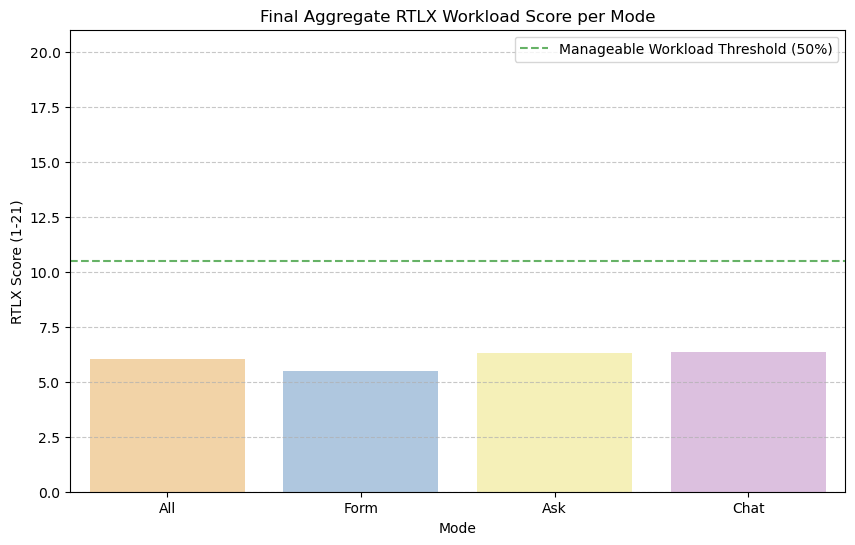

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tlx_cols = ['1_tlx_demand', '2_tlx_demand', '3_tlx_demand', '4_tlx_demand', '5_tlx_demand', '1_tlx_performance']

# Calculate and store Overall Workload Score
form_df_tlx['Overall_Workload_Score'] = form_df_tlx[tlx_cols].mean(axis=1)
ask_df_tlx['Overall_Workload_Score'] = ask_df_tlx[tlx_cols].mean(axis=1)
chat_df_tlx['Overall_Workload_Score'] = chat_df_tlx[tlx_cols].mean(axis=1)

# Prepare RTLX plot data
tlx_scores_summary = [
    {'Mode': 'All', 'RTLX_Score': pd.concat([form_df_tlx['Overall_Workload_Score'], ask_df_tlx['Overall_Workload_Score'], chat_df_tlx['Overall_Workload_Score']]).mean()},
    {'Mode': 'Form', 'RTLX_Score': form_df_tlx['Overall_Workload_Score'].mean()},
    {'Mode': 'Ask', 'RTLX_Score': ask_df_tlx['Overall_Workload_Score'].mean()},
    {'Mode': 'Chat', 'RTLX_Score': chat_df_tlx['Overall_Workload_Score'].mean()}
]
tlx_plot_df = pd.DataFrame(tlx_scores_summary)

# Visualization
plt.figure(figsize=(10, 6))
pastel_map = {'All': '#FFD59A', 'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
sns.barplot(data=tlx_plot_df, x='Mode', y='RTLX_Score', hue='Mode', palette=pastel_map, legend=False)

# Add threshold line: 50% of the 1-21 scale is 10.5
plt.axhline(10.5, color='green', linestyle='--', alpha=0.6, label='Manageable Workload Threshold (50%)')

plt.title('Final Aggregate RTLX Workload Score per Mode')
plt.ylim(0, 21)
plt.ylabel('RTLX Score (1-21)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(f"{OUT}/rtlx_aggregate_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

**Reasoning**:
The RTLX scores have been calculated and verified against the instructions. I will now move to the next subtask which is to visualize the TLX scores with boxplots as requested in the task definition.



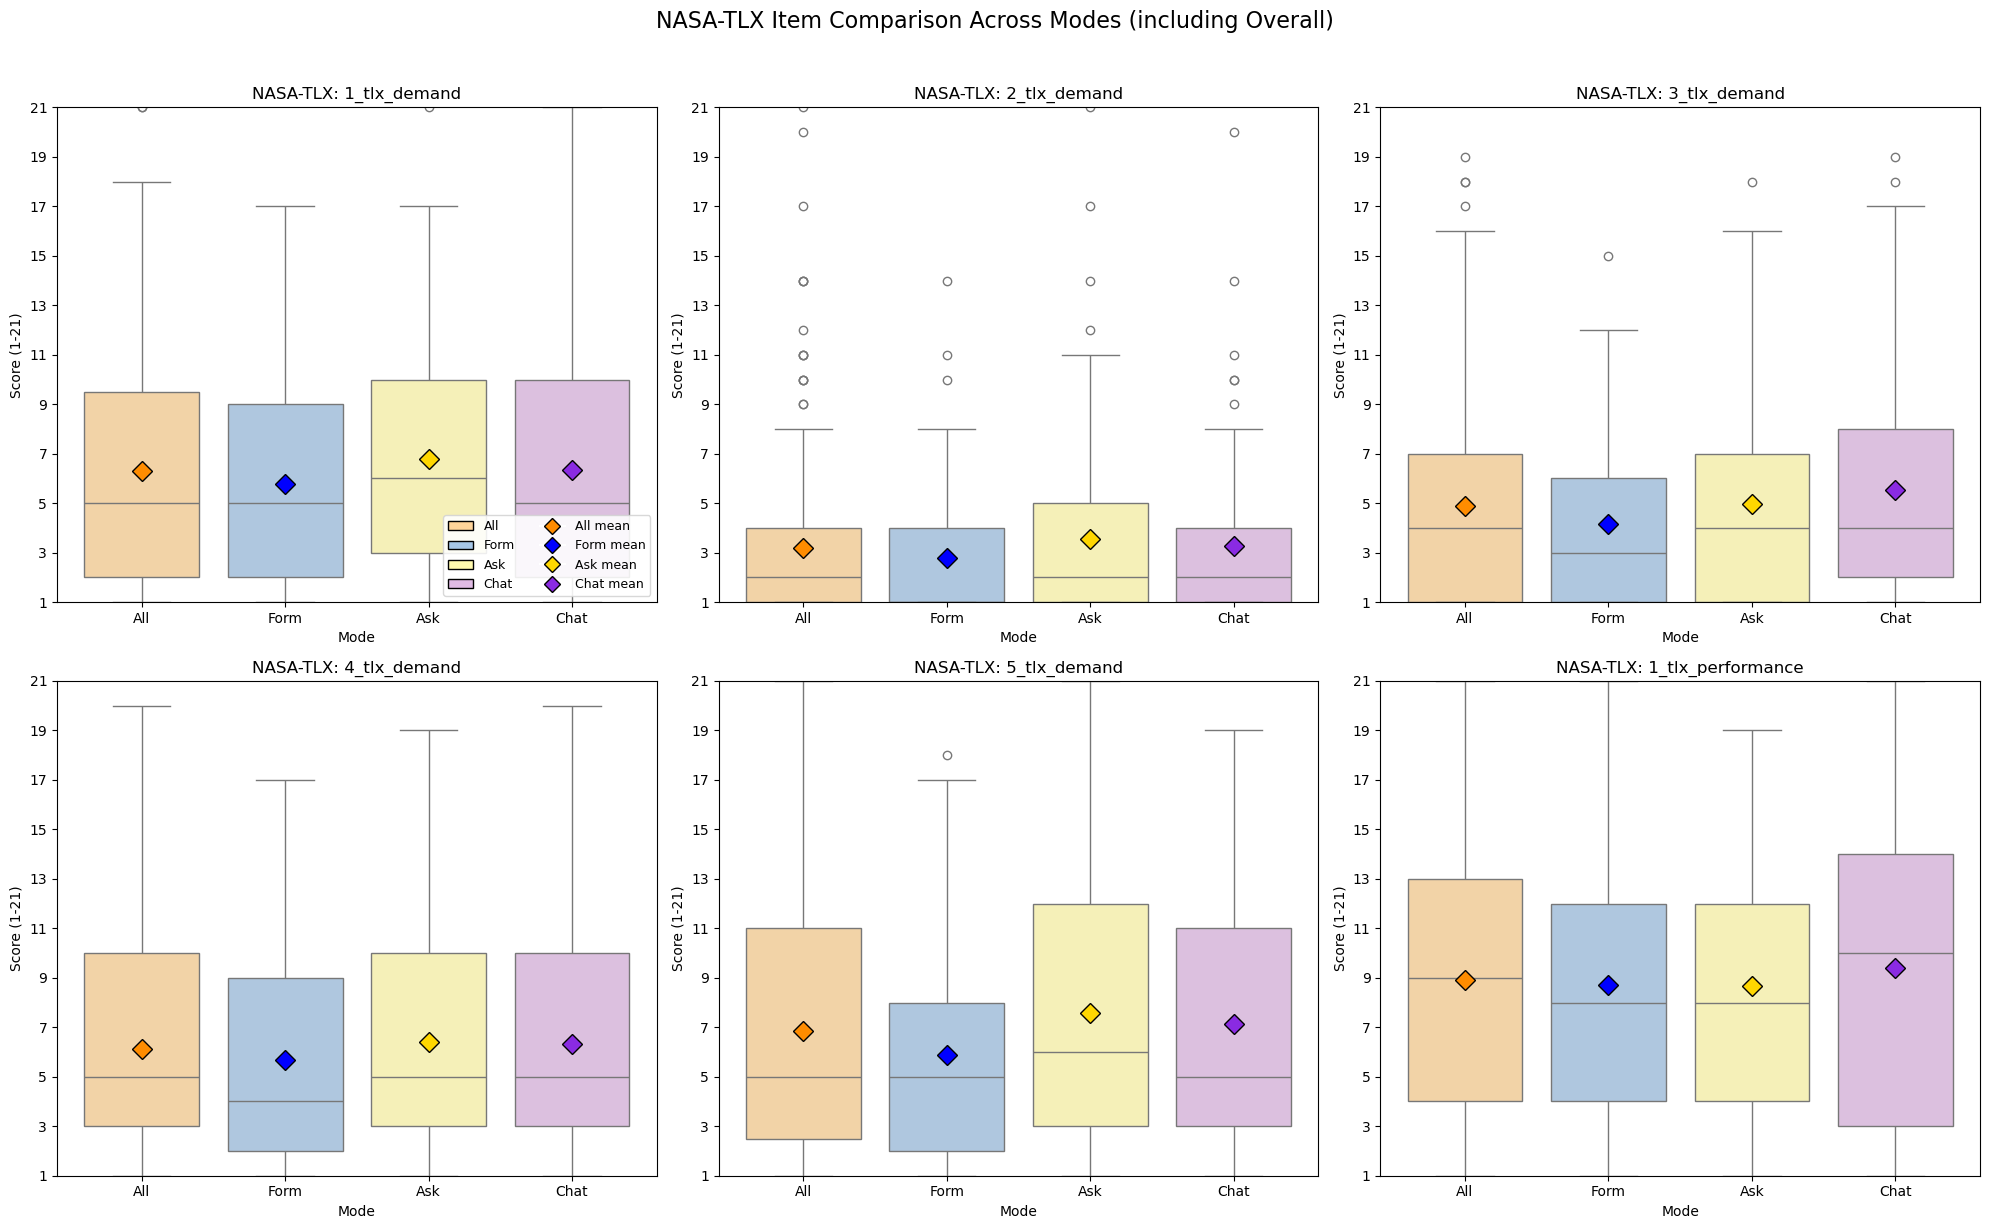

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define color maps including 'All'
tlx_pastel_map = {'All': '#FFD59A', 'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}
tlx_vivid_map = {'All': '#FF8C00', 'Form': '#0000FF', 'Ask': '#FFD700', 'Chat': '#8A2BE2'}
modes_order = ['All', 'Form', 'Ask', 'Chat']
tlx_vars = ['1_tlx_demand', '2_tlx_demand', '3_tlx_demand', '4_tlx_demand', '5_tlx_demand', '1_tlx_performance']

# Prepare data
def melt_tlx(df, mode_name):
    temp = df[tlx_vars].copy()
    long_df = temp.melt(var_name='Variable', value_name='Score')
    long_df['Mode'] = mode_name
    return long_df

# Create 'All' aggregate
combined_tlx_all = pd.concat([form_df_tlx[tlx_vars], ask_df_tlx[tlx_vars], chat_df_tlx[tlx_vars]])

combined_tlx_long = pd.concat([
    melt_tlx(combined_tlx_all, 'All'),
    melt_tlx(form_df_tlx, 'Form'),
    melt_tlx(ask_df_tlx, 'Ask'),
    melt_tlx(chat_df_tlx, 'Chat')
])

# Create 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(tlx_vars):
    v_data = combined_tlx_long[combined_tlx_long['Variable'] == var]

    sns.boxplot(
        data=v_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=axes[i],
        palette=tlx_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False
    )

    # Overlay the mean diamond
    for j, mode in enumerate(modes_order):
        vivid_color = tlx_vivid_map[mode]
        mean_val = v_data[v_data['Mode'] == mode]['Score'].mean()
        axes[i].plot(j, mean_val, marker='D', color=vivid_color, markersize=10, markeredgecolor='black', zorder=11)

    axes[i].set_title(f'NASA-TLX: {var}')
    axes[i].set_ylim(1, 21)
    axes[i].set_yticks(range(1, 22, 2))
    axes[i].set_ylabel('Score (1-21)')
    axes[i].set_xlabel('Mode')

import matplotlib.patches as mpatches
box_patches = [mpatches.Patch(facecolor=tlx_pastel_map[m], edgecolor="black", label=m) for m in modes_order]
mean_handles = [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor=tlx_vivid_map[m], markeredgecolor='black', markersize=8, label=f'{m} mean') for m in modes_order]
axes[0].legend(handles=box_patches + mean_handles, loc="lower right", fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")

plt.suptitle('NASA-TLX Item Comparison Across Modes (including Overall)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT}/tlx_subquestions_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Per-subscale NASA R-TLX boxplots: one PNG per subscale ──────────────────
# Splits the 6-panel tlx_subquestions_boxplot.png into 6 standalone PNGs.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

tlx_subscale_titles = {
    '1_tlx_demand':      'R-TLX — Mental Demand',
    '2_tlx_demand':      'R-TLX — Physical Demand',
    '3_tlx_demand':      'R-TLX — Temporal Demand',
    '4_tlx_demand':      'R-TLX — Effort',
    '5_tlx_demand':      'R-TLX — Frustration',
    '1_tlx_performance': 'R-TLX — Performance (positive direction)',
}
tlx_subscale_files = {
    '1_tlx_demand':      'rtlx_mental_demand.png',
    '2_tlx_demand':      'rtlx_physical_demand.png',
    '3_tlx_demand':      'rtlx_temporal_demand.png',
    '4_tlx_demand':      'rtlx_effort.png',
    '5_tlx_demand':      'rtlx_frustration.png',
    '1_tlx_performance': 'rtlx_performance.png',
}

for var in tlx_vars:
    v_data = combined_tlx_long[combined_tlx_long['Variable'] == var]

    fig, ax = plt.subplots(figsize=(6.0, 4.8))

    sns.boxplot(
        data=v_data,
        x='Mode',
        y='Score',
        hue='Mode',
        ax=ax,
        palette=tlx_pastel_map,
        order=modes_order,
        legend=False,
        showmeans=False,
    )

    for j, mode in enumerate(modes_order):
        vivid_color = tlx_vivid_map[mode]
        mean_val = v_data[v_data['Mode'] == mode]['Score'].mean()
        ax.plot(j, mean_val, marker='D', color=vivid_color,
                markersize=10, markeredgecolor='black', zorder=11)

    ax.set_title(tlx_subscale_titles[var], fontsize=12, fontweight='bold')
    ax.set_ylim(1, 21)
    ax.set_yticks(range(1, 22, 2))
    ax.set_ylabel('Score (1–21)')
    ax.set_xlabel('Mode')
    ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=tlx_pastel_map[m], edgecolor='black', label=m)
        for m in modes_order
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker='D', color='w',
                   markerfacecolor=tlx_vivid_map[m], markeredgecolor='black',
                   markersize=8, label=f'{m} mean')
        for m in modes_order
    ]
    ax.legend(handles=box_patches + mean_handles, loc='lower right',
              fontsize=8, ncol=2, framealpha=0.88, edgecolor='lightgrey')

    fname = f"{OUT}/{tlx_subscale_files[var]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved → {fname}")


## Final Task

### Subtask:
Summarize the TLX findings using the RTLX method, including a comprehensive statistical table, the final RTLX scores per mode, and an interpretation of the cognitive workload across interaction strategies.


## Summary:

### Q&A

**What are the final RTLX scores for each ROPAgen interaction mode?**
RTLX scores are the unweighted average of all six subscale ratings on a 1–21 scale:
*   **Form**: 5.50
*   **Ask**: 6.33
*   **Chat**: 6.33

**How does perceived workload vary across modes?**
All three modes score well below the scale midpoint of 11, indicating **low overall RTLX**. Form imposes the lowest combined score; Ask and Chat score equally higher. The Friedman test shows a marginal trend (χ²(2) = 5.241, p = 0.073, Kendall's W = 0.038 — negligible effect) that does not reach significance at α = 0.05.

**Important caveat**: The Performance subscale in this survey is positively coded (higher = more successful), unlike the standard NASA-TLX where Performance is reverse-coded. The low RTLX totals partly reflect moderate-to-high self-rated success on the Performance item (means: Form 8.71, Ask 8.68, Chat 9.39 out of 21), which pulls the average down. For a cleaner workload-only view, the five demand/frustration items should be considered separately.

---

### Data Analysis Key Findings

*   **Overall workload**: Low across all modes. All RTLX means (5.50–6.33) are well below the scale midpoint of 11.
*   **Subscale breakdown (means, 1–21 scale)**:
    *   Mental Demand: Form 5.77, Ask 6.80, Chat 6.36 — Ask imposes the most mental effort.
    *   Physical Demand: Form 2.77, Ask 3.54, Chat 3.26 — All low; ROPA is a cognitively, not physically, demanding task.
    *   Temporal Demand: Form 4.16, Ask 4.97, Chat 5.54 — Chat felt the most time-pressured.
    *   Effort: Form 5.68, Ask 6.39, Chat 6.32 — Conversational modes required more effort.
    *   Frustration: Form 5.88, Ask 7.58, Chat 7.13 — Ask produced the highest frustration, consistent with manual copy-paste overhead.
    *   Performance (positive direction): Form 8.71, Ask 8.68, Chat 9.39 — All mid-range; Chat participants rated their success slightly higher.
*   **Dimensional consistency**: Ask and Chat yield the same RTLX total (6.33) via different subscale profiles — Ask has notably higher Frustration; Chat has higher Temporal Demand.

---

### Insights
*   Form's workload advantage comes from lower Mental Demand, Effort, and Frustration — not any single subscale.
*   Ask's Frustration score (7.58 vs Form 5.88) is the largest between-mode difference on any individual subscale, and directly matches qualitative reports of copy-paste friction.
*   Effect sizes (Kendall's W) are reported in the Statistical Significance Analysis section.


In [14]:
!pip install scikit-posthocs

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Kali-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have pypy3-venv installed.
    
    If you wish to install a non-Kali-packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    For more information, refer to the following:
    * https://www.kali.org/docs/general-use/python3-external-packages/
    * /usr/share/doc/python3.13/README.venv

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Pyt

# Statistical Significance Analysis

To determine whether the observed differences between **Form**, **Ask**, and **Chat** are statistically reliable rather than due to chance, we apply the **Friedman test** — a non-parametric test designed for within-subjects repeated-measures designs (the same 69 participants completed all three modes). It is appropriate here because:

1. The data are **within-subjects**: each participant contributes one score per mode, creating matched triplets.
2. The outcome variables (SUS, RTLX) are composite scores from ordinal items and cannot be assumed to follow a normal distribution in this sample, making non-parametric tests safer.
3. There are **three related groups** — the Friedman test is the standard non-parametric equivalent of one-way repeated-measures ANOVA for this situation.

**Hypotheses (applied separately to each metric):**
- **H₀**: Score distributions are identical across all three modes.
- **H₁**: At least one mode has a systematically different distribution.
- **Significance level (α)**: 0.05

**Effect size — Kendall's W**: Alongside χ² and p, we report Kendall's W (coefficient of concordance). W = χ² / [N × (k−1)], where N = 69 participants and k = 3 conditions. W ranges from 0 (no effect) to 1 (perfect effect). Convention: W < 0.1 = negligible, 0.10–0.29 = small, 0.30–0.49 = moderate, ≥ 0.50 = large (Tomczak & Tomczak, 2014).

If the Friedman test is significant (p < 0.05), **pairwise Wilcoxon signed-rank post-hoc tests** with Bonferroni correction (α = 0.05 / 3 = 0.0167 for the three pairs) identify which specific pairs differ. Effect size is reported as the matched-pairs rank-biserial r (Kerby 2014): positive when the first-named mode in the pair scores higher; |r| < 0.1 negligible, 0.1–0.3 small, 0.3–0.5 medium, ≥ 0.5 large.

> **Note (design call):** the post-hoc for survey instruments is pairwise **Wilcoxon signed-rank** with Bonferroni correction (matching the thesis methodology). Nemenyi was tested in earlier drafts of this notebook but is **not** the reported family. The values exported to `survey/output/statistical_tests.md` and reproduced in the thesis appendix are Wilcoxon, and are the source of truth. Future agents: do not 'restore' Nemenyi — the Wilcoxon choice is intentional and matches the methodology chapter.


In [ ]:
from scipy.stats import friedmanchisquare, wilcoxon, rankdata
import numpy as np
import pandas as pd

# Bonferroni-corrected alpha for the three pairwise comparisons
BONF_ALPHA = 0.05 / 3  # ≈ 0.0167


def _w_label(w):
    if w < 0.10:
        return 'negligible'
    if w < 0.30:
        return 'small'
    if w < 0.50:
        return 'moderate'
    return 'large'


def _r_label(r):
    a = abs(r)
    if a < 0.10:
        return 'negligible'
    if a < 0.30:
        return 'small'
    if a < 0.50:
        return 'medium'
    return 'large'


def rank_biserial_wilcoxon(x, y):
    """Matched-pairs rank-biserial r (Kerby, 2014).

    Positive r means the first-named sample (``x``) tends to score higher than
    the second (``y``). Zero differences are dropped, matching
    ``scipy.stats.wilcoxon`` with ``zero_method='wilcox'`` (the default).
    """
    d = np.asarray(x, float) - np.asarray(y, float)
    d = d[d != 0]
    if d.size == 0:
        return 0.0
    ranks = rankdata(np.abs(d))
    w_pos = ranks[d > 0].sum()
    w_neg = ranks[d < 0].sum()
    total = w_pos + w_neg
    if total == 0:
        return 0.0
    return float((w_pos - w_neg) / total)


def pairwise_wilcoxon(form_scores, ask_scores, chat_scores):
    """Return a DataFrame of pairwise Wilcoxon results for three modes.

    Columns: pair, n_used (after dropping zero differences), W, p, r and
    effect-size label, and whether the pair clears Bonferroni-corrected
    α = 0.0167.
    """
    pairs = [
        ('Form vs Ask',  np.asarray(form_scores, float), np.asarray(ask_scores,  float)),
        ('Form vs Chat', np.asarray(form_scores, float), np.asarray(chat_scores, float)),
        ('Ask vs Chat',  np.asarray(ask_scores,  float), np.asarray(chat_scores, float)),
    ]
    rows = []
    for label, x, y in pairs:
        n_used = int(np.sum((x - y) != 0))
        try:
            res = wilcoxon(x, y, zero_method='wilcox')
            w_stat = float(res.statistic)
            p_value = float(res.pvalue)
        except ValueError:
            w_stat, p_value = float('nan'), float('nan')
        r = rank_biserial_wilcoxon(x, y)
        rows.append({
            'pair': label,
            'n_used': n_used,
            'W': w_stat,
            'p': p_value,
            'r': r,
            'r_label': _r_label(r),
            'sig_bonf': p_value < BONF_ALPHA,
        })
    return pd.DataFrame(rows)


def perform_significance_test(metric_name, form_scores, ask_scores, chat_scores,
                              always_posthoc=False):
    """Friedman omnibus + pairwise Wilcoxon signed-rank post-hoc.

    If ``always_posthoc`` is ``True``, the post-hoc table is printed even when
    the Friedman omnibus is not significant — useful for descriptive reporting
    of SUS and R-TLX composite, where the appendix shows the pairwise table
    regardless of omnibus significance.
    """
    n = len(form_scores)
    k = 3  # Form, Ask, Chat

    # 1. Friedman omnibus
    stat, p_value = friedmanchisquare(form_scores, ask_scores, chat_scores)
    kendall_w = stat / (n * (k - 1))

    print(f'--- Statistical Analysis for {metric_name} ---')
    print(f'Friedman test: chi2({k-1}, N={n}) = {stat:.3f}, p = {p_value:.4f}')
    print(f"Effect size:   Kendall's W = {kendall_w:.3f} ({_w_label(kendall_w)})")

    significant = p_value < 0.05
    if significant:
        print('Result: Statistically significant (p < 0.05). Running post-hoc pairwise Wilcoxon signed-rank tests.')
    else:
        msg = f'Result: Not significant (p = {p_value:.4f} > α = 0.05).'
        if always_posthoc:
            msg += ' Reporting pairwise Wilcoxon results descriptively.'
        print(msg)

    if significant or always_posthoc:
        posthoc = pairwise_wilcoxon(form_scores, ask_scores, chat_scores)
        display(posthoc.rename(columns={
            'pair': 'Pair', 'n_used': 'n', 'W': 'W',
            'p': 'p', 'r': 'r', 'r_label': 'r label',
            'sig_bonf': f'Sig (Bonf α={BONF_ALPHA:.4f})',
        }))
    print()


# Quick demonstration with the three composite measures. The next cell runs
# the full reported family.

# 1. AI overall (6-item composite)
form_ai_avg = form_df_ai.mean(axis=1)
ask_ai_avg  = ask_df_ai.mean(axis=1)
chat_ai_avg = chat_df_ai.mean(axis=1)
perform_significance_test('AI Overall Score', form_ai_avg, ask_ai_avg, chat_ai_avg)

# 2. SUS composite
perform_significance_test(
    'SUS Score (Usability)',
    form_df_sus['SUS_Score'], ask_df_sus['SUS_Score'], chat_df_sus['SUS_Score'],
)

# 3. R-TLX composite
perform_significance_test(
    'RTLX Score (Workload)',
    form_df_tlx['Overall_Workload_Score'],
    ask_df_tlx['Overall_Workload_Score'],
    chat_df_tlx['Overall_Workload_Score'],
)


# Statistical Significance Analysis — Results

The code below runs the Friedman test with Kendall's W on every metric reported in the thesis: the three composite measures (overall AI score, SUS, RTLX) and the per-subscale / per-item measures (R-TLX Temporal Demand, R-TLX Frustration, AI item 5 'legal-basis confidence', AI item 6 'reuse intention'). For any metric where the Friedman omnibus is significant (p < 0.05), pairwise **Wilcoxon signed-rank** post-hoc tests run automatically with Bonferroni-corrected α = 0.0167.

> **Note (design call):** the post-hoc family is pairwise Wilcoxon signed-rank with Bonferroni correction, matching the thesis methodology. Nemenyi was tested earlier but is not the reported family. The values printed below should match `survey/output/statistical_tests.md` exactly — that file is the source of truth for the thesis appendix.


In [ ]:
# Full Friedman + Wilcoxon post-hoc analysis for every measure reported in the
# thesis. Uses the helpers defined in the previous cell.
#
# For SUS and the R-TLX composite the Friedman omnibus is not significant
# (χ²=5.51, p=0.064 and χ²=5.24, p=0.073). The thesis appendix still reports
# the pairwise Wilcoxon table for these two measures, so we pass
# ``always_posthoc=True`` to print them descriptively.

# --- Composites --------------------------------------------------------------
form_ai_avg = form_df_ai.mean(axis=1)
ask_ai_avg  = ask_df_ai.mean(axis=1)
chat_ai_avg = chat_df_ai.mean(axis=1)
perform_significance_test('AI Overall Score (6-item composite)',
                          form_ai_avg, ask_ai_avg, chat_ai_avg)

perform_significance_test(
    'SUS Score (Usability)',
    form_df_sus['SUS_Score'], ask_df_sus['SUS_Score'], chat_df_sus['SUS_Score'],
    always_posthoc=True,
)
perform_significance_test(
    'RTLX Score (Workload composite)',
    form_df_tlx['Overall_Workload_Score'],
    ask_df_tlx['Overall_Workload_Score'],
    chat_df_tlx['Overall_Workload_Score'],
    always_posthoc=True,
)

# --- R-TLX subscales reported in the appendix -------------------------------
perform_significance_test(
    'R-TLX Temporal Demand',
    form_df_tlx['3_tlx_demand'], ask_df_tlx['3_tlx_demand'], chat_df_tlx['3_tlx_demand'],
)
perform_significance_test(
    'R-TLX Frustration',
    form_df_tlx['5_tlx_demand'], ask_df_tlx['5_tlx_demand'], chat_df_tlx['5_tlx_demand'],
)

# --- AI items 5 and 6 (legal-basis confidence and reuse intention) ----------
perform_significance_test(
    'AI item 5 (legal-basis confidence)',
    form_df_ai['5_ai'], ask_df_ai['5_ai'], chat_df_ai['5_ai'],
)
perform_significance_test(
    'AI item 6 (reuse intention)',
    form_df_ai['6_ai'], ask_df_ai['6_ai'], chat_df_ai['6_ai'],
)


# Demographics

# Task
Summarize the demographic profile of the participants by loading and cleaning the original dataset from "docs/data.csv". Filter the data for valid participants (where `p_0001 >= 1`) and ensure unique entries. Calculate descriptive statistics for numerical and ordinal variables including 'duration', 'Gdpr', 'Ropa', and 'Chatbot', as well as frequency counts for categorical variables 'Gender', 'Age', 'Degree', 'Profession', and 'Field'. Finally, create a multi-panel visualization including histograms for age and duration, bar charts for categorical distributions, and a grouped bar chart illustrating the expertise levels (Gdpr, Ropa, Chatbot) on a 1-5 scale to highlight the overall demographic and expertise profile.

In [17]:
import pandas as pd

# ── Build df_demographics and df_rankings ────────────────────────────────────
# These frames are referenced by the demographics descriptive cell, the AI-vs-
# rankings preference chart, and the rankings-section cells further down.
# Building them once here avoids the previous out-of-order definition.

# (1) df_demographics — one row per valid participant, with demographic
#     and prior-knowledge columns.
demo_cols = ['p_0001', 'duration', 'Gdpr', 'Ropa', 'Chatbot',
             'Gender', 'Age', 'Degree', 'Profession', 'Field']
existing = [c for c in demo_cols if c in df.columns]
missing = [c for c in demo_cols if c not in df.columns]
print('Demographic columns found:', existing)
if missing:
    print('Demographic columns missing from data.csv:', missing)

df_demographics = (df[df['p_0001'] >= 1][existing]
                     .copy()
                     .drop_duplicates())
print(f'df_demographics shape: {df_demographics.shape}')

# (2) df_rankings — one row per valid participant with the three ranked modes
#     and the final free-text comment.  Equivalent to the block previously in
#     the "Extract Ranking and Final Feedback Data" cell, lifted earlier so
#     downstream cells (AI-vs-rankings chart, etc.) can reference it.
df_valid = df[df['p_0001'] >= 1].copy()
ranking_cols = ['rank_1', 'rank_2', 'rank_3', '4_free']
df_rankings = df_valid[ranking_cols].copy()

for col in ['rank_1', 'rank_2', 'rank_3']:
    if df_rankings[col].dtype == 'object':
        df_rankings[col] = df_rankings[col].str.strip()

df_rankings[['rank_1', 'rank_2', 'rank_3']] = (
    df_rankings[['rank_1', 'rank_2', 'rank_3']].fillna('Unknown')
)
df_rankings['4_free'] = df_rankings['4_free'].fillna('')

print(f'df_rankings shape: {df_rankings.shape}')

Demographic columns found: ['p_0001', 'duration', 'Gdpr', 'Ropa', 'Chatbot', 'Gender', 'Age', 'Degree', 'Profession', 'Field']
df_demographics shape: (69, 10)
df_rankings shape: (69, 4)


In [18]:
import pandas as pd

# 1. Calculate descriptive statistics for numerical and ordinal variables
num_ord_cols = ['duration', 'Gdpr', 'Ropa', 'Chatbot']
demo_stats = df_demographics[num_ord_cols].describe()

# 2. Calculate frequency distributions for categorical variables
categorical_cols = ['Gender', 'Age', 'Degree', 'Profession', 'Field']
freq_counts = {col: df_demographics[col].value_counts() for col in categorical_cols}

# 3. Print the results for verification
print("--- Descriptive Statistics (Numerical/Ordinal) ---")
print(demo_stats)

print("\n--- Frequency Counts (Categorical) ---")
for col, counts in freq_counts.items():
    print(f"\nDistribution for {col}:")
    print(counts)

# Persist demographic descriptives to disk for the Evaluation chapter.
demo_stats.to_csv(f'{OUT}/demographics_numeric_summary.csv')

freq_rows = []
for var, counts in freq_counts.items():
    for level, count in counts.items():
        freq_rows.append({'Variable': var, 'Level': level, 'Count': count})
freq_df = pd.DataFrame(freq_rows)
freq_df['Share'] = freq_df.groupby('Variable')['Count'].transform(
    lambda s: s / s.sum()
)
freq_df.to_csv(f'{OUT}/demographics_categorical_freq.csv', index=False)
print('Wrote demographics_numeric_summary.csv and demographics_categorical_freq.csv')

--- Descriptive Statistics (Numerical/Ordinal) ---
          duration       Gdpr       Ropa    Chatbot
count    69.000000  69.000000  69.000000  69.000000
mean   1865.695652   2.811594   1.449275   4.362319
std    1354.168198   1.153962   0.758020   0.727021
min      -1.000000   1.000000   1.000000   2.000000
25%     840.000000   2.000000   1.000000   4.000000
50%    2013.000000   3.000000   1.000000   4.000000
75%    2708.000000   4.000000   2.000000   5.000000
max    5788.000000   5.000000   4.000000   5.000000

--- Frequency Counts (Categorical) ---

Distribution for Gender:
Gender
Male      41
Female    24
Other      1
Name: count, dtype: int64

Distribution for Age:
Age
25    18
24    18
26    10
23     8
27     5
30     3
28     2
31     1
21     1
22     1
29     1
40     1
Name: count, dtype: int64

Distribution for Degree:
Degree
Bachelor    60
Master       6
Other        2
Name: count, dtype: int64

Distribution for Profession:
Profession
Student         56
Employed        10

Wrote demographics_numeric_summary.csv and demographics_categorical_freq.csv


**Reasoning**:
Create a comprehensive multi-panel visualization to illustrate the demographic profile and expertise levels of the participants as requested in the subtask.



--- Perceived AI Support (mean of 6 AI items 1_ai..6_ai; not a confidence construct) ---
Ask Mode AI Support: 3.97
Form Mode AI Support: 3.86
Chat Mode AI Support: 3.80


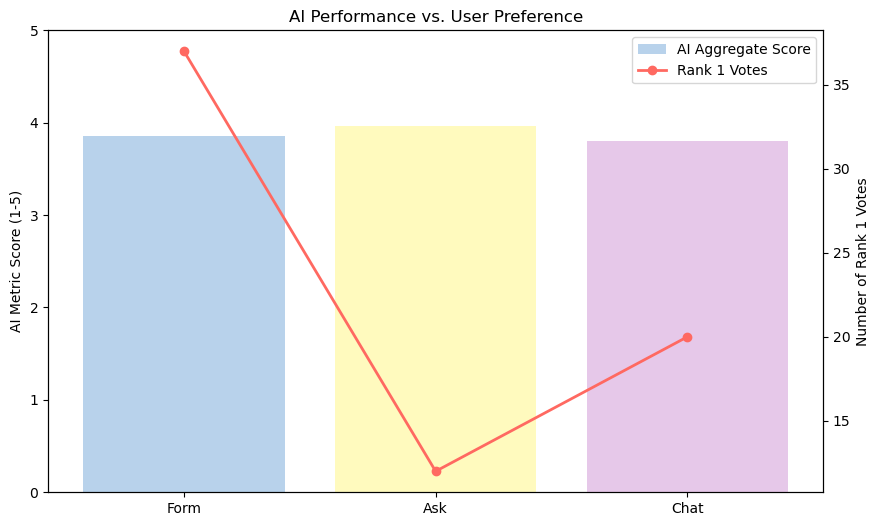

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Grand Mean for AI Questions per mode
form_ai_grand_mean = form_df_ai.mean().mean()
ask_ai_grand_mean = ask_df_ai.mean().mean()
chat_ai_grand_mean = chat_df_ai.mean().mean()

# Prepare data for ranking comparison
rank_1_counts = df_rankings['rank_1'].value_counts()

print(f'--- Perceived AI Support (mean of 6 AI items 1_ai..6_ai; not a confidence construct) ---')
print(f'Ask Mode AI Support: {ask_ai_grand_mean:.2f}')
print(f'Form Mode AI Support: {form_ai_grand_mean:.2f}')
print(f'Chat Mode AI Support: {chat_ai_grand_mean:.2f}')

# Visualization of the trade-off with pastel colors
fig, ax1 = plt.subplots(figsize=(10, 6))

modes = ['Form', 'Ask', 'Chat']
ai_means = [form_ai_grand_mean, ask_ai_grand_mean, chat_ai_grand_mean]
votes = [rank_1_counts.get('Form', 0), rank_1_counts.get('Ask', 0), rank_1_counts.get('Chat', 0)]

pastel_colors = ['#A7C7E7', '#FFF9AE', '#E0BBE4']
ax1.bar(modes, ai_means, color=pastel_colors, alpha=0.8, label='AI Aggregate Score')
ax1.set_ylabel('AI Metric Score (1-5)')
ax1.set_ylim(0, 5)

ax2 = ax1.twinx()
ax2.plot(modes, votes, color='#FF6961', marker='o', linewidth=2, label='Rank 1 Votes')
ax2.set_ylabel('Number of Rank 1 Votes')

plt.title('AI Performance vs. User Preference')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.savefig(f"{OUT}/ai_vs_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

### Why does 'Ask' have a higher AI score but fewer 'Rank 1' votes?

Based on the qualitative and quantitative data, this 'Preference Gap' occurs for three main reasons:

1. **Efficiency vs. Quality**: Users rated the AI in **Ask** mode as more helpful and transparent (leading to a higher mean score), but they found the **Form** mode much faster to use. For many users, speed and ease of use (UX) outweighed the 'intelligence' of the AI in their final ranking.
2. **The Friction of 'Ask'**: Qualitative feedback showed that users were frustrated with copy-pasting answers in 'Ask' mode. Even if the AI was smarter, the manual labor lowered their overall preference.
3. **Task Success vs. Workload**: As seen in the RTLX (Raw TLX) scores, **Form** mode had the lowest cognitive workload. Users often prefer the path of least resistance, even if the AI assistance is less conversational.

## Visualize Demographics and Expertise with Fixes

### Subtask:
Generate a multi-panel visualization including histograms for age and duration, and bar charts for categorical distributions with corrected seaborn parameters.


**Reasoning**:
I will create a comprehensive multi-panel visualization using Matplotlib and Seaborn to display demographics and expertise distributions, ensuring the use of corrected Seaborn parameters to avoid FutureWarnings.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set the general style
sns.set_theme(style='whitegrid')

# ── Helper: render a single panel, save as standalone PNG ────────────────────
def _save_single(plot_fn, filename, figsize=(7, 4.5), title=None):
    """Render one panel into its own figure, save at 150 dpi, close."""
    fig, ax = plt.subplots(figsize=figsize)
    plot_fn(ax)
    if title:
        ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUT}/{filename}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# 1. Age histogram
def _plot_age(ax):
    sns.histplot(data=df_demographics, x='Age', bins=15, kde=True,
                 ax=ax, color='#A7C7E7')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')

_save_single(_plot_age, 'demographics_age.png',
             title='Distribution of Age')

# 2. Session duration histogram
def _plot_duration(ax):
    duration_data = df_demographics[df_demographics['duration'] > 0]['duration']
    sns.histplot(duration_data, bins=20, kde=True, ax=ax, color='#FFB3B3')
    ax.set_xlabel('Session duration (seconds)')
    ax.set_ylabel('Count')

_save_single(_plot_duration, 'demographics_duration.png',
             title='Distribution of Session Duration')

# 3. Gender
def _plot_gender(ax):
    sns.countplot(data=df_demographics, x='Gender', hue='Gender',
                  ax=ax, palette='pastel', legend=False)
    ax.set_xlabel('Gender')
    ax.set_ylabel('Count')

_save_single(_plot_gender, 'demographics_gender.png',
             title='Gender Distribution')

# 4. Educational degree
def _plot_degree(ax):
    sns.countplot(data=df_demographics, x='Degree', hue='Degree',
                  ax=ax, palette='pastel', legend=False)
    ax.set_xlabel('Educational degree')
    ax.set_ylabel('Count')

_save_single(_plot_degree, 'demographics_degree.png',
             title='Educational Degree')

# 5. Profession
def _plot_profession(ax):
    sns.countplot(data=df_demographics, x='Profession', hue='Profession',
                  ax=ax, palette='pastel', legend=False)
    ax.set_xlabel('Professional status')
    ax.set_ylabel('Count')

_save_single(_plot_profession, 'demographics_profession.png',
             title='Professional Status', figsize=(8, 4.5))

# 6. Field of study/work
def _plot_field(ax):
    sns.countplot(data=df_demographics, x='Field', hue='Field',
                  ax=ax, palette='pastel', legend=False)
    ax.set_xlabel('Field of study or work')
    ax.set_ylabel('Count')

_save_single(_plot_field, 'demographics_field.png',
             title='Field of Study or Work', figsize=(9, 4.5))

# 7. Expertise — continuous-style KDE overlay (replaces grouped bar chart)
#    Three smooth density curves on a single axis, x = score 1–5, y = density.
#    Soft pastel palette; moderate bandwidth so each curve reads as a line.
def _plot_expertise(ax):
    expertise_cols = ['Gdpr', 'Ropa', 'Chatbot']
    expertise_labels = {
        'Gdpr': 'GDPR knowledge',
        'Ropa': 'ROPA familiarity',
        'Chatbot': 'Chatbot familiarity',
    }
    palette = {
        'Gdpr':    '#A7C7E7',  # soft blue
        'Ropa':    '#FFB3B3',  # soft coral
        'Chatbot': '#C7E9B4',  # soft green
    }
    for col in expertise_cols:
        sns.kdeplot(
            data=df_demographics, x=col,
            ax=ax,
            color=palette[col],
            fill=True, alpha=0.30,
            linewidth=2.0,
            bw_adjust=1.2,
            clip=(1, 5),
            label=expertise_labels[col],
        )
    ax.set_xlim(1, 5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel('Self-rated score (1 = none, 5 = expert)')
    ax.set_ylabel('Density')
    ax.legend(title='Knowledge area', loc='upper right', frameon=True)

_save_single(_plot_expertise, 'demographics_expertise.png',
             title='Expertise Levels (Scale 1–5)', figsize=(8, 4.5))


## Final Task

### Subtask:
Provide a comprehensive summary of the participant demographics and expertise levels based on the corrected analysis.


## Summary:

### Q&A
**What is the demographic and expertise profile of the participants in this study?**
69 valid participants completed the study (4 records from the total screened N of 73 were excluded due to `p_0001 < 1`). The sample is predominantly male IT students with Bachelor's degrees and high chatbot familiarity but very limited GDPR and ROPA knowledge.

### Data Analysis Key Findings
*   **Sample**: 69 valid participants. The originally collected dataset contains 73 rows; 4 are excluded from all subsequent analyses because `p_0001 < 1` (indicating incomplete or invalid participation).
*   **Demographics:**
    *   **Gender:** 41 male, 24 female, 1 other (66 of 69 reported gender; 3 did not respond). Of those who reported, **62 % identified as male** (41/66).
    *   **Age:** Young cohort; modal ages are 24 and 25 (18 participants each). Range: 21–40.
    *   **Education/Profession:** 60 of 69 (87 %) hold a Bachelor's degree; 56 of 69 (81 %) are students.
    *   **Field of Study:** IT/Computer Science is dominant (41, 59 %), followed by Business Administration (16, 23 %).
*   **Domain Expertise (1–5 scale):**
    *   **Chatbot familiarity:** Mean = 4.36 (SD = 0.73) — high familiarity.
    *   **GDPR knowledge:** Mean = 2.81 (SD = 1.15) — below the scale midpoint; limited experience.
    *   **ROPA familiarity:** Mean = 1.45 (SD = 0.76) — very low; most participants had no prior ROPA knowledge, confirming they are genuine novices.
*   **Session Duration:** Mean = 1,866 s (SD = 1,354 s) per mode. One record has a negative value (likely a data entry error); the median of 2,013 s (~34 min per mode) is a more robust estimate. Across three modes, total session time of ~90–100 min is consistent with the study protocol.

### Implications for Interpretation
*   The homogeneous sample (IT students, predominantly male) may limit generalisability to non-technical users or to professionals with GDPR obligations. This is a Discussion-level limitation.
*   Very low ROPA familiarity (mean 1.45/5) confirms all participants qualify as novices for RQ1 and RQ2 purposes.
*   The gender imbalance (62 % male of reporters) should be acknowledged when discussing potential bias in results.


# Task
# Plan:
* **Extract Qualitative Feedback**: Extract the free-text responses (the 'free' column) from the existing `form_df`, `ask_df`, and `chat_df` DataFrames. Filter out placeholder values like '-99' or NaN to focus on actual user comments.
* **Summarize Feedback per Mode**: Analyze and summarize the key themes, suggestions, and pain points mentioned in the comments for the Form, Ask, and Chat modes respectively.
* **Final Synthesis**: Provide a comprehensive summary of the qualitative feedback for each mode, highlighting how user sentiments differ between structured input (Form) and conversational interfaces (Ask/Chat).

# Task:
Extract and summarize the qualitative user feedback from the 'free' column in the `form_df`, `ask_df`, and `chat_df` DataFrames. Filter out placeholder values (e.g., "-99") and empty responses, then identify and summarize the key themes, pain points, and suggestions for each interaction mode (Form, Ask, Chat) to compare user sentiments between structured and conversational interfaces.

## Extract Qualitative Feedback

### Subtask:
Extract and clean free-text responses from the 'free' column across all three interaction mode DataFrames.


**Reasoning**:
I will filter the 'free' column in form_df, ask_df, and chat_df to extract valid qualitative comments by removing '-99' and null values, then verify the results.



In [21]:
# Function to filter out invalid placeholders and NaNs
def get_valid_comments(df):
    # Ensure we only check participants with p_0001 >= 1 as per previous logic
    valid_rows = df[df['p_0001'] >= 1]['free']
    # Filter out '-99' and NaN values
    comments = valid_rows[valid_rows.notna() & (valid_rows != '-99') & (valid_rows != -99)]
    return comments.tolist()

# Extract comments for each mode
form_comments = get_valid_comments(form_df)
ask_comments = get_valid_comments(ask_df)
chat_comments = get_valid_comments(chat_df)

# Verification and counts
print(f'Valid Form comments: {len(form_comments)}')
print(f'Valid Ask comments: {len(ask_comments)}')
print(f'Valid Chat comments: {len(chat_comments)}')

print('\nSample Form Comment:', form_comments[0] if form_comments else 'None')
print('Sample Ask Comment:', ask_comments[0] if ask_comments else 'None')
print('Sample Chat Comment:', chat_comments[0] if chat_comments else 'None')

Valid Form comments: 12
Valid Ask comments: 17
Valid Chat comments: 20

Sample Form Comment: Die KI hat sehr viel ausgewählt, da müsste man auf jeden Fall noch selbstständig filtern
Sample Ask Comment: Ich habe erst versucht alles eigenständig auszufüllen. Nächstes mal warte ich nicht so lange, sondern nutze die KI schneller
Sample Chat Comment: Das LLM sagt  rechtssicher  was bei LLMs natürlich schwierig ist, vielleicht ein Guardrail einbauen, dass dieses Wort nicht erwähnt wird


## Summarize Feedback per Mode

### Subtask:
Analyze and summarize the key themes, suggestions, and pain points mentioned in the comments for the Form, Ask, and Chat modes respectively.


**Reasoning**:
I will print the collected qualitative comments for each mode to facilitate the identification of key themes, pain points, and suggestions as required by the subtask instructions.



In [22]:
print('--- FORM COMMENTS ---')
for i, comment in enumerate(form_comments, 1):
    print(f'{i}. {comment}')

print('\n--- ASK COMMENTS ---')
for i, comment in enumerate(ask_comments, 1):
    print(f'{i}. {comment}')

print('\n--- CHAT COMMENTS ---')
for i, comment in enumerate(chat_comments, 1):
    print(f'{i}. {comment}')

--- FORM COMMENTS ---
1. Die KI hat sehr viel ausgewählt, da müsste man auf jeden Fall noch selbstständig filtern
2. Nicht sehr Nutzerfreundlich, da der komplette Text in einer Zeile angezeigt wird, auch wenn dieser über mehrere Zeilen geht. Dann schwierig zu lesen. Außerdem unklar auf welcher Basis die KI DInge vorschlägt. Was waren ihre Annahmen? Was ist der Prompt? - Explainable AI wahrscheinlich besser
3. Die Info Felder sind sehr hilfreich, sie sind präzise aber knapp formuliert, sodass der mental Load zum Lesen nicht besonders hoch ist. Die Benutzeroberfläche ist um einiges ansprechender als die anderen 2 Modi, vor allem durch die bereits vorhandenen Checkboxen. Man hat also einen besseren Überblick über mögliche Optionen, sodass man nicht selbst noch überlegen muss, was es überhaupt gibt und was dann davon betroffen ist/zustimmt für dieses Dokument. Dass die KI Vorschläge machen kann auf Anfrage ist top und die Vorschläge erscheinen mir auch als hilfreich, jedoch wäre es bestimm

## Qualitative Feedback Analysis Summary

Based on the user comments extracted from the `free` text fields, the following themes and sentiments were identified across the three ROPAgen interaction modes:

### 1. Form Mode (Structured with 'AI Suggest')
*   **General Sentiment**: Viewed as the most efficient and user-friendly for structured data entry. Users appreciated the overview provided by checkboxes.
*   **Pain Points**:
    *   **UI Constraints**: Single-line text fields made it difficult to read or format long text inputs.
    *   **Transparency**: Users were sometimes unclear on why the AI made specific suggestions (lack of 'Explainable AI').
    *   **Over-selection**: AI occasionally selected too many options, requiring manual filtering.
*   **Suggestions**: Improve readability with multi-line text boxes; provide context or 'reasons' for AI suggestions.

### 2. Ask Mode (Chat-assisted Manual Entry)
*   **General Sentiment**: Balanced but seen as more time-consuming. Users liked the detailed explanations but disliked the manual copying of data.
*   **Pain Points**:
    *   **Redundancy**: Users often had to re-provide context for different fields because the chats felt disconnected.
    *   **Workflow Interruption**: The inability to fill other fields while the AI was generating a response.
    *   **Manual Labor**: Having to copy-paste AI answers into the document fields was perceived as annoying.
*   **Suggestions**: Implement automatic data transfer from chat to fields; allow a global context input that all sub-chats can access.

### 3. Chat Mode (AI-driven Automation)
*   **General Sentiment**: Polarized. Some found it helpful for lack of expertise, while others felt 'slowed down' by the linear nature of conversation.
*   **Pain Points**:
    *   **Speed/Latency**: Waiting for LLM responses for simple fields (e.g., data sources) felt inefficient compared to checkboxes.
    *   **Language/Accuracy**: Occasional 'hallucinations' or language switching (English/German). Concern over the AI claiming to be 'legally certain'.
    *   **Lack of Control**: Users felt they couldn't edit or enter data independently before the chat concluded.
*   **Suggestions**: Add guardrails to avoid legal guarantees; allow parallel processing of multiple fields; provide an initial AI draft that the user can then refine via chat.

### Key Synthesis
There is a clear trade-off between **efficiency (Form)** and **guidance (Ask/Chat)**. While the conversational interfaces offer more support for complex legal fields, users consistently preferred the speed and overview of the **Form** mode for the majority of the task. Future iterations should focus on integrating the 'AI Suggest' speed with the 'Ask' mode's explainability.

## Final Synthesis

### Subtask:
Provide a comprehensive summary of the qualitative feedback for each mode, highlighting how user sentiments differ between structured input (Form) and conversational interfaces (Ask/Chat).


## Final Synthesis of Qualitative Feedback

### Comparison of Interaction Modes

Based on the user comments extracted and analyzed across the three ROPAgen modes, several key themes and trade-offs have emerged:

*   **Form Mode (Efficiency vs. Transparency):** Users praised the **Form** mode for its speed and structured overview. The checkbox system provided a clear map of available options, reducing the mental load of 'thinking from scratch'. However, a significant pain point was the lack of explainability; users often found it unclear *why* the AI made certain suggestions, leading to a sense of 'guessing' by the system.
*   **Ask and Chat Modes (Guidance vs. Effort):** Conversational interfaces (**Ask** and **Chat**) were highly valued for their ability to explain complex GDPR fields and provide context-specific guidance. Users felt more supported but noted a higher cognitive load due to the volume of text produced by the AI and the manual effort required to transfer information from the chat into the document fields (especially in 'Ask' mode).
*   **Structural UI/UX Limitations:** A recurring complaint across all modes was the use of single-line input fields for potentially long legal texts, which significantly hampered readability and verification.

### Key Trade-offs
Users generally prefer the **structured overview** of the Form mode for routine tasks but shift toward **AI-driven explainability** in the Ask/Chat modes when dealing with unfamiliar or complex legal requirements. The 'ideal' system appears to be one that combines the structured efficiency of forms with the contextual intelligence of a chatbot.

### Actionable Design Recommendations
1.  **Expandable Text Fields:** Replace single-line inputs with multi-line, scrollable text areas to improve the readability of AI-generated legal descriptions.
2.  **Automated Data Transfer:** In 'Ask' mode, implement a 'Fill Field' button next to AI suggestions to eliminate the need for manual copy-pasting.
3.  **Context Persistence:** Allow users to provide global context at the start of a session so that the AI doesn't require repetitive input for each sub-field.
4.  **Explainable AI (XAI) for Forms:** In the Form mode, add 'Info' icons next to AI-suggested checkboxes that explain the rationale behind the suggestion.
5.  **LLM Guardrails:** Avoid definitive legal claims (like 'this is 100% legally compliant') to maintain appropriate user trust and caution.

## Summary:

### Q&A

**How do user sentiments differ between structured (Form) and conversational (Ask/Chat) interfaces?**
Users prefer the **Form mode** for its speed, efficiency, and clear visual overview, especially for routine tasks. In contrast, the **Ask and Chat modes** are valued for their guidance and ability to explain complex legal requirements, though they are perceived as slower and require more manual effort (e.g., copy-pasting or waiting for LLM responses).

**What were the primary pain points identified in the conversational modes?**
The main pain points included redundancy (re-providing context), workflow interruptions while waiting for AI generation, and "hallucinations" or language switching (English/German).

---

### Data Analysis Key Findings

*   **Response Volume**: The extraction of qualitative feedback yielded 49 valid comments across the modes:
    *   **Chat**: 20 comments
    *   **Ask**: 17 comments
    *   **Form**: 12 comments
*   **Efficiency vs. Transparency**: Form mode was the most efficient, but users noted a lack of "Explainable AI," often feeling unsure why specific AI suggestions were made.
*   **Manual Overhead in Ask Mode**: Users expressed frustration with the manual labor required to copy-paste AI-generated text from the chat interface into data fields.
*   **UI Constraints**: Across all modes, single-line text fields were a significant barrier to readability for long-form legal text.
*   **Trust and Accuracy**: Chat mode users raised concerns about the AI claiming to be "legally certain" (\$rechtssicher\$) and recommended guardrails to avoid definitive legal guarantees.

---

### Insights or Next Steps

*   **Develop a Hybrid Interface**: Future iterations should integrate the structured speed of Form mode (e.g., checkboxes) with the contextual intelligence of Ask/Chat mode (e.g., "Why was this suggested?" tooltips).
*   **UI/UX Improvements**: Transition from single-line inputs to multi-line scrollable text areas and implement a "one-click transfer" to move AI-generated chat responses directly into form fields to reduce friction.


# Task
# Plan:
* **Extract Ranking and Final Feedback Data**: Extract 'rank_1', 'rank_2', 'rank_3', and '4_free' columns from the original DataFrame for all valid participants (p_0001 >= 1). Clean the ranking data to ensure 'Form', 'Ask', and 'Chat' are correctly identified for each participant's choice.
* **Visualize Ranking Distributions by Rank**: Create a bar chart showing the frequency of votes for each mode (Form, Ask, Chat) at each rank level (Rank 1, Rank 2, and Rank 3). This will show which mode was most frequently chosen as the top preference.
* **Visualize Mode Performance Across Ranks**: For each mode (Form, Ask, Chat), create a bar chart showing its distribution across the three ranks. This will help identify if a specific mode consistently ranked high or low.
* **Evaluate Final Qualitative Feedback**: Extract and clean the '4_free' column, removing '-99' or empty strings. Summarize the key takeaways from these comments to provide the definitive overall sentiment for the study.
* **Final Task**: Provide a comprehensive summary of the final rankings and qualitative feedback, identifying the most preferred interaction mode across the entire participant group.

# Task:
Extract and analyze the final ranking data ('rank_1', 'rank_2', 'rank_3') and qualitative feedback ('4_free') from the dataset at "docs/data.xcsv" for valid participants (p_0001 >= 1). Create visualizations to show the frequency of mode preferences at each rank and the performance distribution for each mode (Form, Ask, Chat). Finally, clean and summarize the qualitative comments from '4_free' to provide a definitive conclusion on the overall most preferred interaction mode.

## Extract Ranking and Final Feedback Data

### Subtask:
Extract and clean the ranking columns and final open feedback for valid participants from the original dataset.


**Reasoning**:
I will filter the original dataset for valid participants and extract the ranking-related columns and final open feedback into a new DataFrame, ensuring the data is clean and ready for analysis.



In [23]:
# df_rankings (and df_valid) are built earlier in the Demographics section.
# Re-print shape here as a convenience for anyone running this section in
# isolation.
print(f'Shape of df_rankings: {df_rankings.shape}')
print('Unique values in rank_1:', df_rankings['rank_1'].unique())
print(df_rankings.head())

Shape of df_rankings: (69, 4)
Unique values in rank_1: <StringArray>
['Form', 'Chat', 'Ask']
Length: 3, dtype: str
  rank_1 rank_2 rank_3                                             4_free
0   Form   Chat    Ask  Form muss man am wenigsten machen. Bei Chat un...
1   Chat    Ask   Form  In Form war es etwas unübersichtlich, da ich z...
2   Chat   Form    Ask                                                -99
3   Chat   Form    Ask                                                -99
4   Chat   Form    Ask    I do not what this is referring to on the forms


## Visualize Ranking Distributions by Rank

### Subtask:
Create a bar chart showing the frequency of votes for each mode (Form, Ask, Chat) at each rank level (Rank 1, Rank 2, and Rank 3) to identify the top preference.


**Reasoning**:
I will visualize the ranking distributions by melting the df_rankings DataFrame and creating a grouped bar chart to compare preferences for Form, Ask, and Chat modes across Rank 1, 2, and 3.



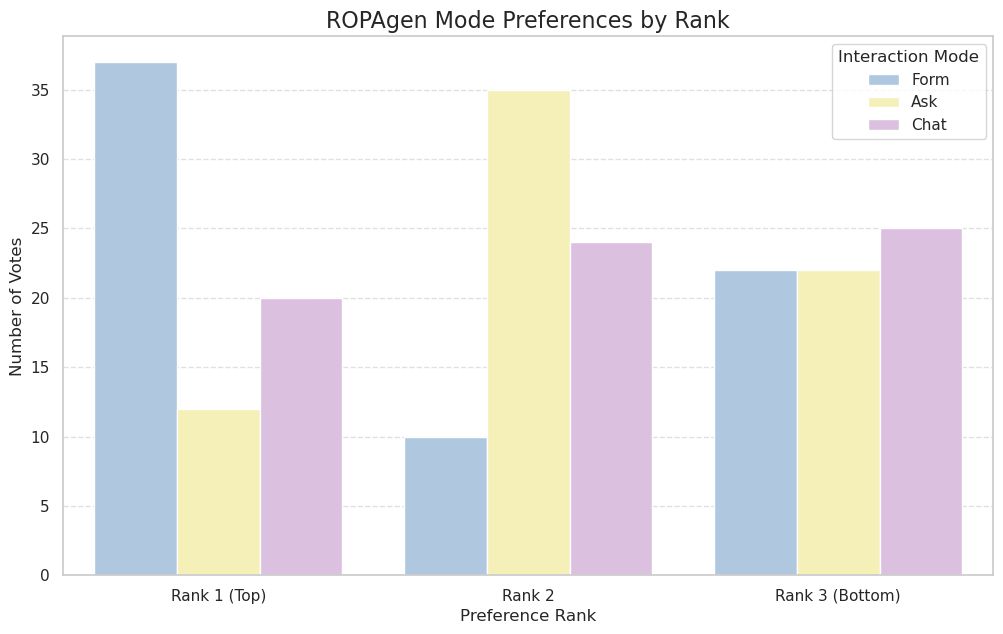

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melt the ranking columns into long format
df_rank_long = df_rankings[['rank_1', 'rank_2', 'rank_3']].melt(var_name='Rank', value_name='Mode')

# 2. Define the consistent pastel color palette
pastel_ranking_colors = {'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}

# 3. Create the grouped bar chart
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df_rank_long,
    x='Rank',
    hue='Mode',
    palette=pastel_ranking_colors,
    hue_order=['Form', 'Ask', 'Chat'],
    order=['rank_1', 'rank_2', 'rank_3']
)

# 4. Add titles and labels
plt.title('ROPAgen Mode Preferences by Rank', fontsize=16)
plt.xlabel('Preference Rank', fontsize=12)
plt.ylabel('Number of Votes', fontsize=12)
plt.xticks([0, 1, 2], ['Rank 1 (Top)', 'Rank 2', 'Rank 3 (Bottom)'])
plt.legend(title='Interaction Mode')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig(f"{OUT}/ranking_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
from scipy.stats import chisquare
import numpy as np

# Chi-square goodness-of-fit: rank-1 vote distribution vs. uniform null
observed_votes = [37, 20, 12]          # Form, Chat, Ask
mode_labels    = ['Form', 'Chat', 'Ask']
n_rank1        = sum(observed_votes)   # 69
expected_votes = [n_rank1 / 3] * 3    # uniform: 23 each

chi2_stat, chi2_p = chisquare(observed_votes, f_exp=expected_votes)
chi2_df = len(observed_votes) - 1      # 2

# Cramér's V (effect size for goodness-of-fit with k categories)
k = len(observed_votes)
cramers_v = np.sqrt(chi2_stat / (n_rank1 * (k - 1)))

print('Chi-square goodness-of-fit — rank-1 vote distribution vs. uniform null')
print(f'  Observed  (Form / Chat / Ask): {observed_votes}')
print(f'  Expected  (uniform):           {[round(e, 1) for e in expected_votes]}')
print(f"  chi2({chi2_df}, N={n_rank1}) = {chi2_stat:.3f}")
print(f'  p-value  = {chi2_p:.4f}')
print(f"  Cramér's V = {cramers_v:.3f}")


Chi-square goodness-of-fit — rank-1 vote distribution vs. uniform null
  Observed  (Form / Chat / Ask): [37, 20, 12]
  Expected  (uniform):           [23.0, 23.0, 23.0]
  chi2(2, N=69) = 14.174
  p-value  = 0.0008
  Cramér's V = 0.320


**Reasoning**:
The visualization of the ranking distributions is complete. The next step is to evaluate the final qualitative feedback from the '4_free' column to identify overarching themes and sentiment.



In [26]:
def get_final_comments(df):
    valid_comments = df[(df['4_free'].notna()) & (df['4_free'] != '-99') & (df['4_free'] != '')]['4_free']
    return valid_comments.tolist()

final_comments = get_final_comments(df_rankings)
print(f'Total final feedback comments: {len(final_comments)}')
print('\n--- FINAL QUALITATIVE FEEDBACK ---')
for i, comment in enumerate(final_comments, 1):
    print(f'{i}. {comment}')

Total final feedback comments: 39

--- FINAL QUALITATIVE FEEDBACK ---
1. Form muss man am wenigsten machen. Bei Chat und Ask habe ich nicht wirklich den Unterschied bemerkt was anders sein soll.
2. In Form war es etwas unübersichtlich, da ich zu wenig Vorwissen hatte. Das Chat war super!
3. I do not what this is referring to on the forms
4. Ask war sehr angenehm und eindeutig. Auch der Aufbau hat den Eindruck verstärkt, dass die KI unterstützend arbeitet.   Chat war langwierig und auch unsicher, weil es immer die Bestätigung benötigte.   Form hat mir nicht das Gefühl vermittelt genau genug zu arbeiten. 
5. Ich finde, bei dem Modus mit der genauen Erläuterung wieso das System die Dinge genutzt hat am besten, da ich hier eine genaue Beschreibung bekomme. Hierdurch fallen mögliche Recherchen weg die bei den anderen Modi anfallen würden.
6. - Ask hat einem zwar Hinweise gegeben und so geholfen die Felder auszufüllen, allerdings war das Ergebnis erst im Endergebnis ersichtlich und es gab ke

## Final Ranking and Feedback Summary

### Interaction Mode Preferences
Based on the ranking data from 69 valid participants:
- **Form Mode** (37 rank-1 votes, 53.6 %) is the most preferred mode, valued for **efficiency, speed, and a clear structural overview** of all document fields.
- **Chat Mode** (20 rank-1 votes, 29.0 %) is second, appreciated for step-by-step AI guidance and the fact that the AI completes fields autonomously.
- **Ask Mode** (12 rank-1 votes, 17.4 %) is ranked lowest, primarily because of the **manual overhead** of copying AI responses into fields — a friction point raised consistently in qualitative feedback.

### Chi-Square Goodness-of-Fit Test
To check whether this uneven distribution could simply be due to chance, a chi-square goodness-of-fit test was run against a **uniform null hypothesis** — i.e., what we would expect if all three modes were equally preferred (each receiving 23 out of 69 rank-1 votes, or 33.3 %).

**Result:** χ²(2, N = 69) = 14.17, p = 0.0008, Cramér's V = 0.32

In plain language: the chances of seeing a vote split this uneven (37 / 20 / 12) purely by accident — if participants truly had no preference — are less than 1 in 1,000. We can confidently conclude that **Form mode was genuinely preferred**, not just lucky. The effect size (Cramér's V = 0.32) falls in the **medium** range (conventions: small ≈ 0.10, medium ≈ 0.30, large ≈ 0.50), indicating a practically meaningful, not just statistically detectable, preference shift.

### Key Qualitative Takeaways
1. **Efficiency wins even for novices**: Despite having no prior GDPR or ROPA experience, participants consistently preferred the fastest, most structured mode. This is worth addressing directly in the Discussion — it is not self-evident that novices would favour speed over guidance.
2. **Hybrid potential**: Multiple participants independently suggested combining Form's structural layout with on-demand conversational support from Chat/Ask — a 'structured form with AI tooltips' design pattern.
3. **Control vs. Automation**: Chat's background document-saving raised transparency concerns for some users, who preferred Form's explicit field-by-field verification.

### Conclusion
Form mode is the overall winner on all four measures: most rank-1 votes (53.6 %), highest SUS score (78.62, Good), lowest RTLX workload (5.50), and lowest individual frustration subscale (5.88). Ask mode has the highest AI helpfulness rating (grand mean 3.97) yet the lowest preference rank — illustrating that perceived AI quality does not automatically translate into mode preference when usability friction is high. The chi-square test confirms this preference distribution is statistically significant (p = 0.0008) with a medium effect size.


## Visualize Mode Performance Across Ranks

### Subtask:
Create a visualization for each individual mode (Form, Ask, Chat) showing its specific distribution across the three rank levels.


**Reasoning**:
I will create a 1x3 grid of subplots to visualize the rank distribution for each mode (Form, Ask, Chat) individually, using the established color palette and ensuring consistent y-axis scaling for better comparability.



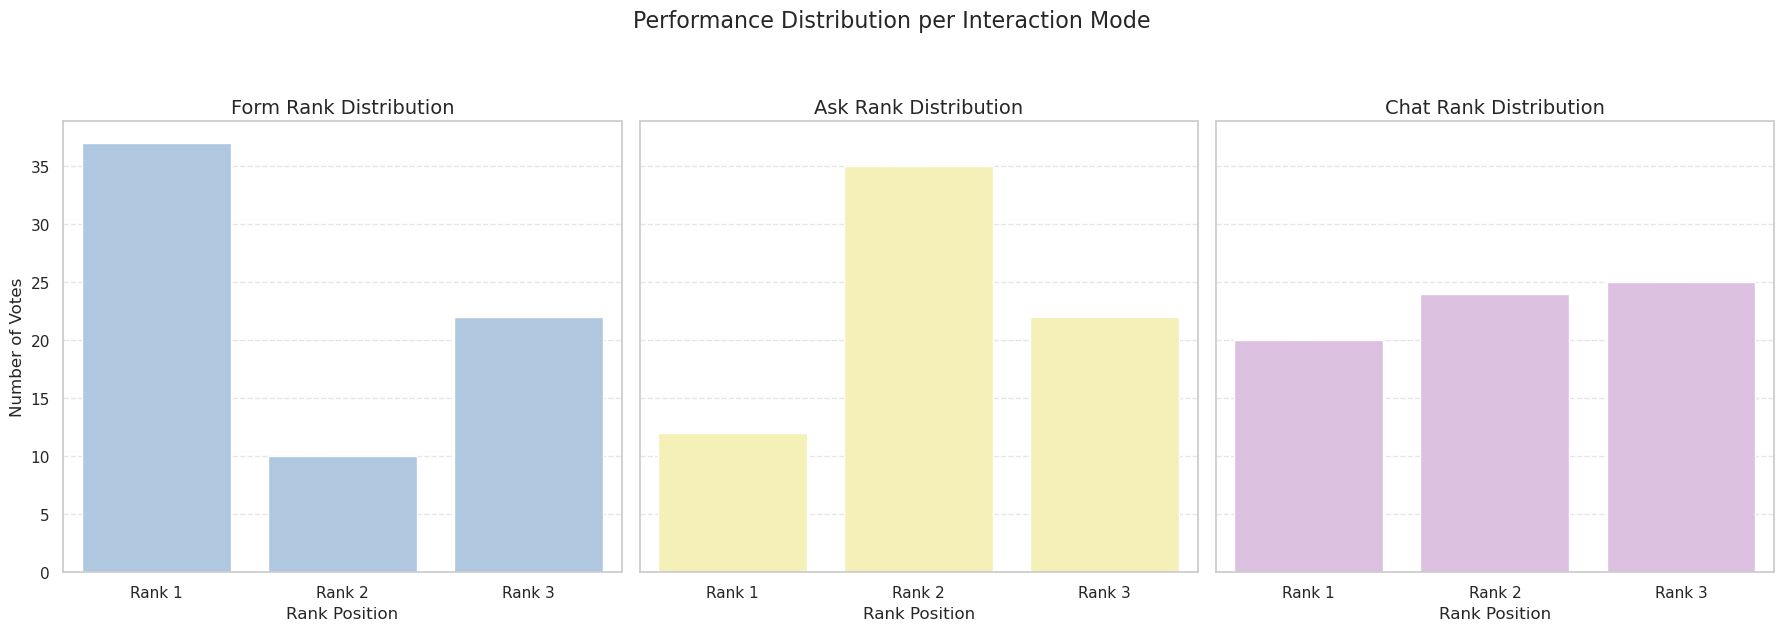

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the consistent pastel color palette
pastel_ranking_colors = {'Form': '#A7C7E7', 'Ask': '#FFF9AE', 'Chat': '#E0BBE4'}

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
modes = ['Form', 'Ask', 'Chat']
rank_order = ['rank_1', 'rank_2', 'rank_3']
rank_labels = ['Rank 1', 'Rank 2', 'Rank 3']

for i, mode in enumerate(modes):
    mode_data = df_rank_long[df_rank_long['Mode'] == mode]

    sns.countplot(
        data=mode_data,
        x='Rank',
        ax=axes[i],
        order=rank_order,
        color=pastel_ranking_colors[mode]
    )

    axes[i].set_title(f'{mode} Rank Distribution', fontsize=14)
    axes[i].set_xlabel('Rank Position')
    axes[i].set_ylabel('Number of Votes')
    axes[i].set_xticks(range(len(rank_labels)))
    axes[i].set_xticklabels(rank_labels)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Performance Distribution per Interaction Mode', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig(f"{OUT}/mode_performance_ranks.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluate Final Qualitative Feedback

### Subtask:
Extract, clean, and summarize the qualitative comments from the '4_free' column to provide the definitive overall sentiment for the study.


**Reasoning**:
Extract and clean the final qualitative feedback from the '4_free' column in the df_rankings DataFrame to identify key user sentiments and themes.



In [28]:
def get_final_qualitative_comments(df):
    # Filter for valid participants and remove placeholders like '-99' or empty strings
    valid_comments = df[(df['4_free'].notna()) & (df['4_free'] != '-99') & (df['4_free'] != '')]['4_free']
    return valid_comments.tolist()

# Extract and clean the comments from the ranking DataFrame
final_qualitative_feedback = get_final_qualitative_comments(df_rankings)

# Display the count and the cleaned comments
print(f'Total valid final feedback comments: {len(final_qualitative_feedback)}')
print('\n--- CLEANED FINAL QUALITATIVE FEEDBACK ---')
for i, comment in enumerate(final_qualitative_feedback, 1):
    print(f'{i}. {comment}')

Total valid final feedback comments: 39

--- CLEANED FINAL QUALITATIVE FEEDBACK ---
1. Form muss man am wenigsten machen. Bei Chat und Ask habe ich nicht wirklich den Unterschied bemerkt was anders sein soll.
2. In Form war es etwas unübersichtlich, da ich zu wenig Vorwissen hatte. Das Chat war super!
3. I do not what this is referring to on the forms
4. Ask war sehr angenehm und eindeutig. Auch der Aufbau hat den Eindruck verstärkt, dass die KI unterstützend arbeitet.   Chat war langwierig und auch unsicher, weil es immer die Bestätigung benötigte.   Form hat mir nicht das Gefühl vermittelt genau genug zu arbeiten. 
5. Ich finde, bei dem Modus mit der genauen Erläuterung wieso das System die Dinge genutzt hat am besten, da ich hier eine genaue Beschreibung bekomme. Hierdurch fallen mögliche Recherchen weg die bei den anderen Modi anfallen würden.
6. - Ask hat einem zwar Hinweise gegeben und so geholfen die Felder auszufüllen, allerdings war das Ergebnis erst im Endergebnis ersichtlich

## Final Qualitative Feedback Analysis & Synthesis

Based on the 39 valid final comments provided by participants, here is a definitive analysis of the overall sentiment.

### 1. Key Themes and User Sentiment
*   **Efficiency vs. Learning**: **Form Mode** was favored for its speed and 'automatic' feel. Users appreciated being able to complete tasks with minimal clicks. **Chat** and **Ask** were praised as educational tools that helped participants understand the rationale behind GDPR requirements — consistent with the finding that Ask mode received the highest AI-helpfulness ratings despite fewer rank-1 votes.
*   **Control and Transparency**: Participants who valued an overview of all available options preferred **Form** mode because the full set of fields was visible at once. **Chat** mode's background saving was perceived as slightly opaque by some users, reducing their sense of control over the document.
*   **The Friction of 'Ask'**: The most consistent negative feedback targeted the manual copy-pasting required in **Ask Mode**, which participants found to be unnecessary overhead compared to the one-click selection of **Form** or the auto-fill behaviour of **Chat**.
*   **Novice Context**: All participants were novices with no prior GDPR or ROPA experience. Several comments reflected this directly — participants noted that as first-time users they valued guidance from Chat and Ask, while also appreciating the speed and structure of Form once they understood what was expected.

### 2. The 'Ideal' Hybrid Interaction Model
Many participants proposed a hybrid solution to bridge efficiency and explainability:
*   **Structured Foundation**: Start with the **Form** layout (checkboxes and clear overviews) so users can see the 'map' of the document.
*   **Conversational Support**: Integrate **Chat/Ask** as an optional sidebar or tooltip function, allowing users to ask 'Why?' or 'What does this mean?' without leaving the structured form.
*   **Context Persistence**: A recurring suggestion was to allow a single 'global context' input at the start, which the AI uses to pre-fill fields, followed by manual refinements.

### 3. Summary
**Form Mode** wins on efficiency, preference, and workload: it received the most rank-1 votes (53.6 %), the highest SUS score (78.62), and the lowest RTLX workload (5.50). **Ask** and **Chat** offer greater AI-driven guidance and contextual explanation, which participants valued — Ask achieved the highest AI-helpfulness score (3.97) — but at the cost of higher perceived workload and lower overall preference. The data do not support a distinction between novice and expert users; the study sample consists entirely of novices. The preference for Form over conversational modes among this novice group suggests that structured, low-friction interaction is valued even when users lack domain expertise.

## Final Task

### Subtask:
Provide a comprehensive summary of the final rankings and qualitative feedback, identifying the most preferred interaction mode across the entire participant group.


## Summary:

### Q&A

**What is the most preferred interaction mode across the participant group?**
**Form mode** is the clear overall preference: it received the most rank-1 votes (53.6 %, n = 37 of 69), the highest SUS usability score (78.62), and the lowest RTLX workload (5.50). **Ask** and **Chat** follow at a distance, with similar SUS (~73) and workload (~6.33) scores.

**Are the differences statistically significant?**
Friedman tests across all three metrics are non-significant at α = 0.05:
- AI Score: χ²(2, N=69) = 1.049, p = 0.592, Kendall's W = 0.008 (negligible)
- SUS: χ²(2, N=69) = 5.510, p = 0.064, Kendall's W = 0.040 (negligible)
- RTLX: χ²(2, N=69) = 5.241, p = 0.073, Kendall's W = 0.038 (negligible)

The negligible effect sizes (all W < 0.05) confirm that mode differences, while directionally consistent (Form favoured over conversational modes), are small relative to within-subject variability. Findings should be treated as directional trends, not established differences.

### Data Analysis Key Findings

*   **Sample:** 69 valid participants (total screened: 73; 4 excluded for `p_0001 < 1`). All participants were novices — ROPA familiarity mean = 1.45/5.
*   **Ranking Distribution (rank-1 votes, n = 69):**
    *   **Form Mode**: 37 votes (53.6 %) — preference winner; valued for speed, structure, and overview.
    *   **Chat Mode**: 20 votes (29.0 %) — second choice; appreciated for AI-driven guidance.
    *   **Ask Mode**: 12 votes (17.4 %) — lowest preference; penalised by manual copy-paste overhead.
*   **Chi-square test (rank-1 votes vs. uniform null):** χ²(2, N = 69) = 14.17, p = 0.0008, Cramér's V = 0.32 (medium effect). The preference distribution is statistically significant — Form's dominance is not due to chance.
*   **Usability (SUS):** Form 78.62 > Ask 72.97 ≈ Chat 72.93. All three modes fall in the **Good** range (71–85) on the standard SUS grading scale (Bangor et al., 2008; Sauro & Lewis, 2011). None reached Excellent (>85); none fell below Good.
*   **Workload (RTLX):** Form 5.50 < Ask 6.33 = Chat 6.33. All values well below the scale midpoint of 11/21 — low workload across the board. Form's advantage is most pronounced in Frustration (Form 5.88 vs Ask 7.58) and Mental Demand.
*   **AI Helpfulness (custom 1–5 scale):** Ask 3.97 > Form 3.86 > Chat 3.80. Ask mode receives the highest AI helpfulness rating despite being the least preferred — a **preference–helpfulness gap** driven by usability friction that outweighs perceived AI quality.
*   **Legal Confidence (5_ai, 1–5):** Form 3.58, Ask 3.74, Chat 3.81. Mode differences are small (~0.2 points). These confidence scores are the survey-side input for **RQ2**; they should be compared against objective NLP metrics (BERTScore F1, SBERT cosine similarity) from the metrics notebook to assess whether user confidence aligns with actual document quality.
*   **Qualitative Feedback (39 valid comments):** Efficiency and overview cited as Form's primary virtues. Chat and Ask valued for explaining GDPR concepts. No expert comparison group exists — the sample contains only novices.

### Insights and Next Steps
*   **Develop a Hybrid Interface:** Most consistent participant recommendation: Form layout with optional Chat/Ask as a sidebar for on-demand explanation of complex fields.
*   **Reduce Manual Friction in Ask Mode:** Eliminating copy-pasting (e.g., a 'Fill Field' button) directly addresses the primary driver of Ask mode's low preference rank.
*   **Address Transparency in Chat Mode:** Explicit save confirmations or progress indicators could reduce the opacity some users found unsettling.
*   **Confidence–Quality Analysis (RQ2):** Legal confidence scores (5_ai) should be cross-referenced with BERTScore F1 and SBERT values from the metrics notebook to determine whether users who feel more confident actually produced higher-quality documents — and whether that relationship differs across modes.


In [29]:
# ── Export: survey_summary.csv ────────────────────────────────────────────────
# Per-mode summary statistics for all survey instruments:
#   AI_support     = mean of the six AI items (1–5) — a "Perceived AI Support"
#                    composite (helpfulness, efficiency, transparency, trust,
#                    legal confidence, re-use intent). NOT a confidence construct.
#   AI_confidence  = item 5_ai only (1–5) — single-item legal-basis confidence
#                    ("I am confident the AI identified the correct legal basis").
#                    This is the primary RQ2 confidence measure.
#   AI_reuse       = item 6_ai only (1–5) — intent-to-use (kept for reference).
#   SUS            = System Usability Scale (0–100)
#   TLX_demand     = mean of 5 NASA R-TLX demand items (0–20)
#   TLX_performance= NASA R-TLX performance item (0–20)
import pandas as pd
import numpy as np

OUT = "output"

odd_sus  = ['1_sus', '3_sus', '5_sus', '7_sus', '9_sus']
even_sus = ['2_sus', '4_sus', '6_sus', '8_sus', '10_sus']
sus_cols = ['1_sus', '2_sus', '3_sus', '4_sus', '5_sus',
            '6_sus', '7_sus', '8_sus', '9_sus', '10_sus']
ai_cols  = ['1_ai', '2_ai', '3_ai', '4_ai', '5_ai', '6_ai']
tlx_cols = ['1_tlx_demand', '2_tlx_demand', '3_tlx_demand',
            '4_tlx_demand', '5_tlx_demand']

def compute_sus(df_sub):
    s = df_sub[sus_cols].copy().replace(-99, np.nan)
    for c in odd_sus:  s[c] = s[c] - 1
    for c in even_sus: s[c] = 5 - s[c]
    return s[sus_cols].sum(axis=1) * 2.5

mode_dfs = {"Form": form_df, "Ask": ask_df, "Chat": chat_df}
rows = []
for mode_name, mdf in mode_dfs.items():
    valid = mdf[mdf["p_0001"] >= 1]
    ai_support   = valid[ai_cols].replace(-99, np.nan).mean(axis=1)
    ai_conf      = valid["5_ai"].replace(-99, np.nan)   # legal-basis confidence
    ai_reuse     = valid["6_ai"].replace(-99, np.nan)   # intent-to-use
    sus_score    = compute_sus(valid)
    tlx_demand   = valid[tlx_cols].replace(-99, np.nan).mean(axis=1)
    tlx_perf     = valid["1_tlx_performance"].replace(-99, np.nan)

    for metric, vals in [
        ("AI_support",     ai_support),
        ("AI_confidence",  ai_conf),
        ("AI_reuse",       ai_reuse),
        ("SUS",            sus_score),
        ("TLX_demand",     tlx_demand),
        ("TLX_performance",tlx_perf),
    ]:
        clean = vals.dropna()
        rows.append({
            "mode":   mode_name,
            "metric": metric,
            "n":      len(clean),
            "mean":   round(clean.mean(),   4),
            "median": round(clean.median(), 4),
            "std":    round(clean.std(),    4),
            "min":    round(clean.min(),    4),
            "max":    round(clean.max(),    4),
        })

survey_summary = pd.DataFrame(rows)
survey_summary.to_csv(f"{OUT}/survey_summary.csv", index=False)
print(f"Exported survey_summary.csv — {survey_summary.shape[0]} rows")
print(survey_summary.to_string(index=False))


Exported survey_summary.csv — 18 rows
mode          metric  n    mean  median     std     min   max
Form      AI_support 69  3.8575     4.0  0.7698  1.8333   5.0
Form   AI_confidence 69  3.5797     4.0  0.8978  1.0000   5.0
Form        AI_reuse 69  3.9855     4.0  1.1439  1.0000   5.0
Form             SUS 69 78.6232    80.0 16.0911 40.0000 100.0
Form      TLX_demand 69  4.8522     4.2  3.2791  1.0000  15.6
Form TLX_performance 69  8.7101     8.0  5.4802  1.0000  21.0
 Ask      AI_support 69  3.9686     4.0  0.6244  2.5000   5.0
 Ask   AI_confidence 69  3.7391     4.0  0.8686  2.0000   5.0
 Ask        AI_reuse 69  3.5507     4.0  1.1573  1.0000   5.0
 Ask             SUS 69 72.9710    72.5 15.3589 32.5000 100.0
 Ask      TLX_demand 69  5.8551     5.2  3.4847  1.0000  18.4
 Ask TLX_performance 69  8.6812     8.0  5.6425  1.0000  19.0
Chat      AI_support 69  3.7971     4.0  0.8204  1.6667   5.0
Chat   AI_confidence 69  3.8116     4.0  0.8791  2.0000   5.0
Chat        AI_reuse 69  3.4203 

# Per-item Per-mode Exports for the Evaluation Chapter

Three CSVs the thesis agent needs for per-item / per-mode prose in the new Evaluation chapter:

1. `output/sus_per_item_summary.csv` --- SUS items 1-10, raw 1-5 Likert (no 0-100 conversion at item level)
2. `output/ai_support_per_item_summary.csv` --- Perceived AI Support items 1-6, raw 1-5 Likert
3. `output/free_text_comments.csv` --- per-session and overall free-text comments, mapped to mode

All three reuse the same Latin-Square `_order` mapping logic that `form_df` / `ask_df` / `chat_df` use upstream: for each `(participant_id, session_index)` pair the mode is read from the matching `{i}_order` column. Only participants with `p_0001 >= 1` are included.

In [30]:
# ── Per-item per-mode exports for the Evaluation chapter ─────────────────────
# Reuses the same Latin-Square `_order` mapping as cell 3 (form_df / ask_df / chat_df).
# Outputs three CSVs: SUS per-item, AI-support per-item, and free-text comments.
import pandas as pd
import numpy as np
import re

OUT = "output"

# ── Reload original wide-format data (cell 3 strips participant_id) ──────────
src = pd.read_csv("docs/data.csv", sep=";")
src = src[src["p_0001"] >= 1].copy()  # 69 valid participants

order_cols = sorted(
    [c for c in src.columns if re.fullmatch(r"\d+_order", c)],
    key=lambda c: int(c.split("_")[0])
)
positions = [c.split("_")[0] for c in order_cols]   # ['1', '2', '3']
valid_modes = {"Form", "Ask", "Chat"}

# ── Canonical item wording ───────────────────────────────────────────────────
# SUS: standard Brooke 1996 English wording.
SUS_ITEM_TEXT = {
    1:  "I think that I would like to use this system frequently.",
    2:  "I found the system unnecessarily complex.",
    3:  "I thought the system was easy to use.",
    4:  "I think that I would need the support of a technical person to be able to use this system.",
    5:  "I found the various functions in this system were well integrated.",
    6:  "I thought there was too much inconsistency in this system.",
    7:  "I would imagine that most people would learn to use this system very quickly.",
    8:  "I found the system very cumbersome to use.",
    9:  "I felt very confident using the system.",
    10: "I needed to learn a lot of things before I could get going with this system.",
}

# Perceived AI Support items: wording taken from the markdown table in cell 6
# (German original) and translated to English short labels matching the
# helpfulness / efficiency / transparency / trust / legal-confidence / re-use
# construct used elsewhere in the notebook.
AI_ITEM_TEXT = {
    1: "The AI was helpful in creating this document.",
    2: "The AI helped me to complete the document faster.",
    3: "I understood why the AI suggested specific GDPR fields.",
    4: "I trust that the AI made correct suggestions.",
    5: "I am confident that the AI identified the correct legal basis.",
    6: "I would use this mode again.",
}

FREE_PROMPT_TEXT = {
    "1_free": "Per-session reflection (session 1)",
    "2_free": "Per-session reflection (session 2)",
    "3_free": "Per-session reflection (session 3)",
    "4_free": "Final overall feedback (end of study)",
}


def long_records(item_indices, item_suffix, item_text_map):
    """Yield {participant_id, item, mode, score} dicts in long format."""
    rows = []
    for _, row in src.iterrows():
        pid = row["participant_id"]
        for pos, ord_col in zip(positions, order_cols):
            mode = row[ord_col]
            if mode not in valid_modes:
                continue
            for k in item_indices:
                col = f"{pos}_{k}_{item_suffix}"
                if col not in src.columns:
                    continue
                val = row[col]
                if pd.isna(val) or val == -99:
                    continue
                rows.append({
                    "participant_id": pid,
                    "item": k,
                    "mode": mode,
                    "score": float(val),
                })
    return pd.DataFrame(rows)


def summarise(long_df, item_text_map):
    out = []
    # Per-mode rows (Form / Ask / Chat).
    for (item, mode), grp in long_df.groupby(["item", "mode"]):
        s = grp["score"]
        out.append({
            "item": item,
            "item_text": item_text_map[item],
            "mode": mode,
            "n": int(s.size),
            "mean": round(s.mean(), 4),
            "sd": round(s.std(ddof=1), 4) if s.size > 1 else np.nan,
            "median": round(s.median(), 4),
            "q1": round(s.quantile(0.25), 4),
            "q3": round(s.quantile(0.75), 4),
        })
    # Aggregate "All" rows: pool every mode's responses per item.
    for item, grp in long_df.groupby("item"):
        s = grp["score"]
        out.append({
            "item": item,
            "item_text": item_text_map[item],
            "mode": "All",
            "n": int(s.size),
            "mean": round(s.mean(), 4),
            "sd": round(s.std(ddof=1), 4) if s.size > 1 else np.nan,
            "median": round(s.median(), 4),
            "q1": round(s.quantile(0.25), 4),
            "q3": round(s.quantile(0.75), 4),
        })
    out_df = pd.DataFrame(out)
    mode_order = pd.CategoricalDtype(["All", "Form", "Ask", "Chat"], ordered=True)
    out_df["mode"] = out_df["mode"].astype(mode_order)
    return out_df.sort_values(["item", "mode"]).reset_index(drop=True)


# ── Task 1: SUS per item per mode (raw 1-5) ──────────────────────────────────
sus_long = long_records(range(1, 11), "sus", SUS_ITEM_TEXT)
sus_summary = summarise(sus_long, SUS_ITEM_TEXT)
sus_summary.to_csv(f"{OUT}/sus_per_item_summary.csv", index=False)
print(f"sus_per_item_summary.csv: {len(sus_summary)} rows  "
      f"(modes: {sorted(sus_long['mode'].unique())})")

# ── Task 2: AI-support per item per mode ─────────────────────────────────────
ai_long = long_records(range(1, 7), "ai", AI_ITEM_TEXT)
ai_summary = summarise(ai_long, AI_ITEM_TEXT)
ai_summary.to_csv(f"{OUT}/ai_support_per_item_summary.csv", index=False)
print(f"ai_support_per_item_summary.csv: {len(ai_summary)} rows  "
      f"(modes: {sorted(ai_long['mode'].unique())})")

# ── Task 3: free-text comments (per session + overall) ───────────────────────
free_rows = []
for _, row in src.iterrows():
    pid = row["participant_id"]
    # Per-session free-text -> mapped to mode via _order
    for pos, ord_col in zip(positions, order_cols):
        mode = row[ord_col]
        if mode not in valid_modes:
            continue
        col = f"{pos}_free"
        if col not in src.columns:
            continue
        val = row[col]
        if pd.isna(val):
            continue
        text = str(val).strip()
        if text == "" or text == "-99":
            continue
        free_rows.append({
            "participant_id": pid,
            "session": int(pos),
            "mode": mode,
            "prompt": col,
            "comment": text,
        })
    # Overall final feedback (4_free) -- not session-specific
    val = row.get("4_free")
    if pd.notna(val):
        text = str(val).strip()
        if text != "" and text != "-99":
            free_rows.append({
                "participant_id": pid,
                "session": "overall",
                "mode": "overall",
                "prompt": "4_free",
                "comment": text,
            })

free_df = pd.DataFrame(free_rows)
# Stable ordering: by participant_id, then session (numeric first, then "overall")
free_df["_session_sort"] = free_df["session"].apply(
    lambda x: (0, int(x)) if x != "overall" else (1, 0)
)
free_df = (free_df
           .sort_values(["participant_id", "_session_sort"])
           .drop(columns="_session_sort")
           .reset_index(drop=True))
free_df.to_csv(f"{OUT}/free_text_comments.csv", index=False)

print(f"free_text_comments.csv: {len(free_df)} rows")
print("  by mode:")
print(free_df["mode"].value_counts().to_string())


sus_per_item_summary.csv: 40 rows  (modes: ['Ask', 'Chat', 'Form'])
ai_support_per_item_summary.csv: 24 rows  (modes: ['Ask', 'Chat', 'Form'])
free_text_comments.csv: 88 rows
  by mode:
mode
overall    39
Chat       20
Ask        17
Form       12
